# eye tracking data

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

all_interactions = pd.read_csv("/content/drive/MyDrive/summary_feedback.csv")
all_clicks = pd.read_csv("/content/drive/MyDrive/click_summary_dataset.csv")

In [28]:
# Distinguish interactions before and after click
# Only interactions before click are meaningful

movie_clicks = all_interactions[all_interactions["Click_AOI_type"] == "Movie"]

first_click = (
    movie_clicks
    .reset_index()                                # turn the index into a column
    .groupby(["UserID", "TaskID"])["index"]      # group by user+task
    .min()                                        # pick the earliest index
    .rename("first_click_index")
    .reset_index()
)

df = (
    all_interactions                              # bring original index into a column
    .merge(first_click, on=["UserID", "TaskID"], how="left")
)

interactions_before_click = df[df.index <= df["first_click_index"]]

In [29]:
# for free browsing
interactions_before_click.loc[interactions_before_click["Fixation_AOI_type"] == "Genre", "Fixation_AOI_Movie_position_in_carousel"] = 0.0
interactions_before_click_free_browsing = interactions_before_click.query("TaskID <= 30").copy()
interactions_before_click_free_browsing = interactions_before_click_free_browsing[
    interactions_before_click_free_browsing["Fixation_AOI_Movie_position_in_carousel"].notna()
]

delete_pairs = []

for (user, task), subset in interactions_before_click_free_browsing.groupby(
    ["UserID", "TaskID"]
):
    click = movie_clicks[
        (movie_clicks["UserID"] == user) & (movie_clicks["TaskID"] == task)
    ]

    visit = (
        subset["Fixation_AOI_Carousel_position"]
        == click["Click_AOI_Carousel_position"].iloc[0]
    ) & (
        subset["Fixation_AOI_Movie_position_in_carousel"]
        == click["Click_AOI_Movie_position_in_carousel"].iloc[0]
    )

    matches = visit.astype(int)
    shifted = matches.shift(1, fill_value=0)
    visit_start = (matches == 1) & (shifted == 0)
    visit_end = (matches == 0) & (shifted == 1)
    num_visits = visit_start.sum()

    if num_visits == 0:
        delete_pairs.append((user, task))


interactions_before_click_free_browsing = interactions_before_click_free_browsing[
    ~interactions_before_click_free_browsing[["UserID", "TaskID"]].apply(
        tuple, axis=1
    ).isin(delete_pairs)
]

In [30]:
out = all_clicks['Movie_Familiarity'].unique()[-3:-1]
keep = all_clicks[~all_clicks["Movie_Familiarity"].isin(out)]
interactions_before_click_free_browsing = interactions_before_click_free_browsing.merge(
    keep[['TaskID', 'UserID']],
    on=['TaskID', 'UserID'],
    how='inner'
)

In [31]:
aoi_col = "Fixation_AOI_type"
user_col = "UserID"
task_col = "TaskID"
order_col = "Timestamp"

x_col = "Fixation_AOI_Carousel_position"
y_col = "Fixation_AOI_Movie_position_in_carousel"

In [32]:
df = interactions_before_click_free_browsing.copy()

dup_col = "duplicate"
cond = (df[x_col] == df[x_col].shift(1)) & (df[y_col] == df[y_col].shift(1)) \
        & (df[user_col] == df[user_col].shift(1)) \
        & (df[task_col] == df[task_col].shift(1))
df[dup_col] = cond
df = df[~df[dup_col]].copy()

In [33]:
df_KINIT = df[df['UserID'].str.contains('KINIT')].copy()
df_UvA = df[df['UserID'].str.contains('UvA')].copy()

In [34]:
stats = df_KINIT.groupby([user_col, task_col, x_col, y_col]).size().reset_index(name='n_visits')
each_carousel = stats.groupby([x_col, user_col, task_col]).size().reset_index().groupby([x_col])[[user_col, task_col]].size().reset_index(name="exam_row")
binary_exam_result_KINIT = stats.groupby([x_col, y_col]).size().reset_index(name='n_users_tasks')
n_pairs = stats.groupby([user_col, task_col]).size().shape[0]
binary_exam_result_KINIT['exam_freq'] = binary_exam_result_KINIT['n_users_tasks'] / n_pairs * 100
binary_exam_result_KINIT = binary_exam_result_KINIT.merge(each_carousel, on = ['Fixation_AOI_Carousel_position'], how='left')
binary_exam_result_KINIT["inner_freq"] = binary_exam_result_KINIT["n_users_tasks"] / binary_exam_result_KINIT["exam_row"] * 100
binary_exam_result_KINIT = binary_exam_result_KINIT[binary_exam_result_KINIT['Fixation_AOI_Movie_position_in_carousel'] !=0]
binary_exam_result_KINIT['exam_freq'] = binary_exam_result_KINIT['exam_freq'] / binary_exam_result_KINIT['exam_freq'].max()

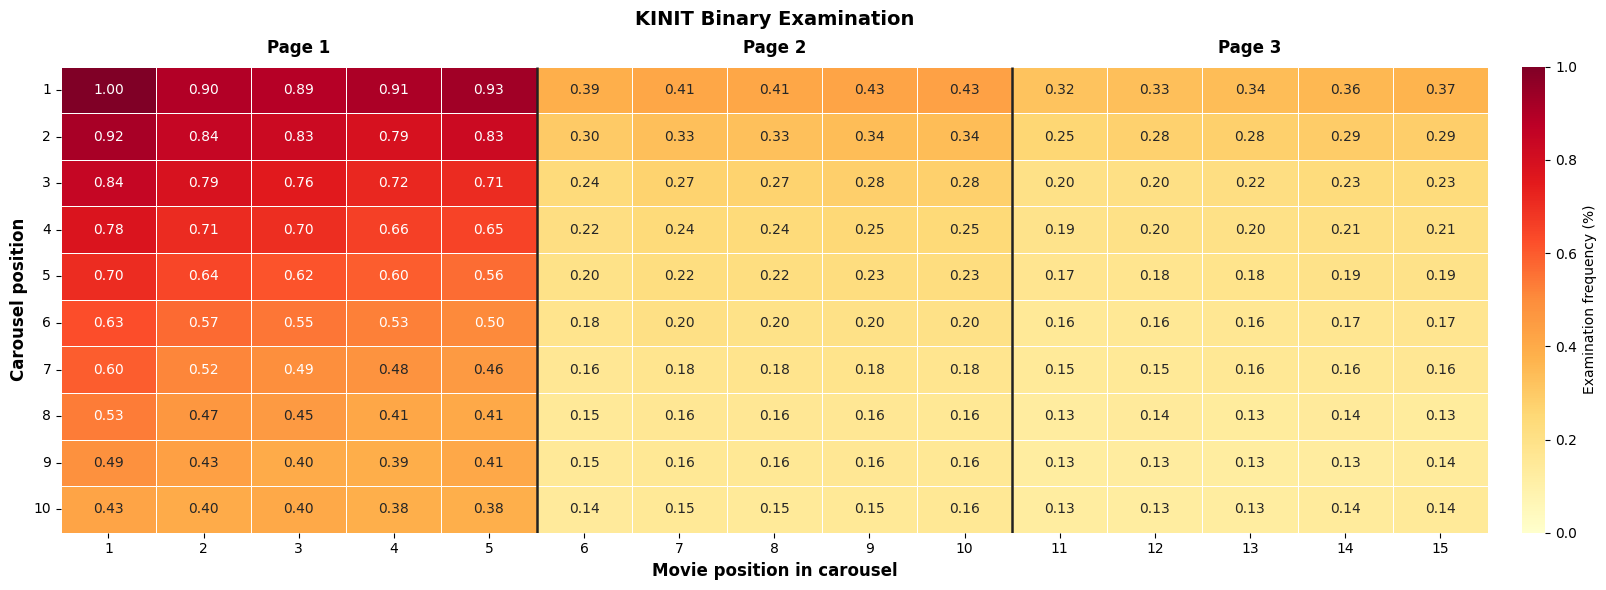

In [35]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pivot_df = binary_exam_result_KINIT.pivot(
    index="Fixation_AOI_Carousel_position",
    columns="Fixation_AOI_Movie_position_in_carousel",
    values="exam_freq"
)

fig, ax = plt.subplots(figsize=(18, 6))

hm = sns.heatmap(
    pivot_df,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,   # ← legend 上限
    linewidths=0.4,      # 细网格线
    linecolor="white",
    cbar_kws={
        "label": "Examination frequency (%)",
        "pad": 0.02      # ← 关键：调小这里
    },
    ax=ax
)


ax.set_title("KINIT Binary Examination", fontsize=14, fontweight="bold", pad=30)
ax.set_xlabel("Movie position in carousel", fontsize=12,
        fontweight="bold")
ax.set_ylabel("Carousel position", fontsize=12,
        fontweight="bold")

# x ticks：title + 1..15
n_cols = len(pivot_df.columns)
xticks = np.arange(n_cols) + 0.5
xlabels = list(range(1, 16))
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, rotation=0)

# y ticks：显示为整数 1..10（去掉 .0）
n_rows = pivot_df.shape[0]
yticks = np.arange(n_rows) + 0.5
ylabels = list(range(1, n_rows + 1))
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, rotation=0)

# --- Vertical separator lines (page boundaries) ---
for x in [5, 10]:
    ax.vlines(x, *ax.get_ylim(), colors="#222222", linewidth=1.8)

# --- Group labels ---
group_centers = {"Page 1": 2.5, "Page 2": 7.5, "Page 3": 12.5}
for label, col_center in group_centers.items():
    ax.text(
        col_center / n_cols,
        1.02,
        label,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )


plt.tight_layout()
plt.savefig("Examination.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

In [36]:
stats = df_UvA.groupby([user_col, task_col, x_col, y_col]).size().reset_index(name='n_visits')
each_carousel = stats.groupby([x_col, user_col, task_col]).size().reset_index().groupby([x_col])[[user_col, task_col]].size().reset_index(name="exam_row")
binary_exam_result_UvA = stats.groupby([x_col, y_col]).size().reset_index(name='n_users_tasks')
n_pairs = stats.groupby([user_col, task_col]).size().shape[0]
binary_exam_result_UvA['exam_freq'] = binary_exam_result_UvA['n_users_tasks'] / n_pairs * 100
binary_exam_result_UvA = binary_exam_result_UvA.merge(each_carousel, on = ['Fixation_AOI_Carousel_position'], how='left')
binary_exam_result_UvA["inner_freq"] = binary_exam_result_UvA["n_users_tasks"] / binary_exam_result_UvA["exam_row"] * 100
binary_exam_result_UvA = binary_exam_result_UvA[binary_exam_result_UvA['Fixation_AOI_Movie_position_in_carousel'] !=0]
binary_exam_result_UvA['exam_freq'] = binary_exam_result_UvA['exam_freq'] / binary_exam_result_UvA['exam_freq'].max()

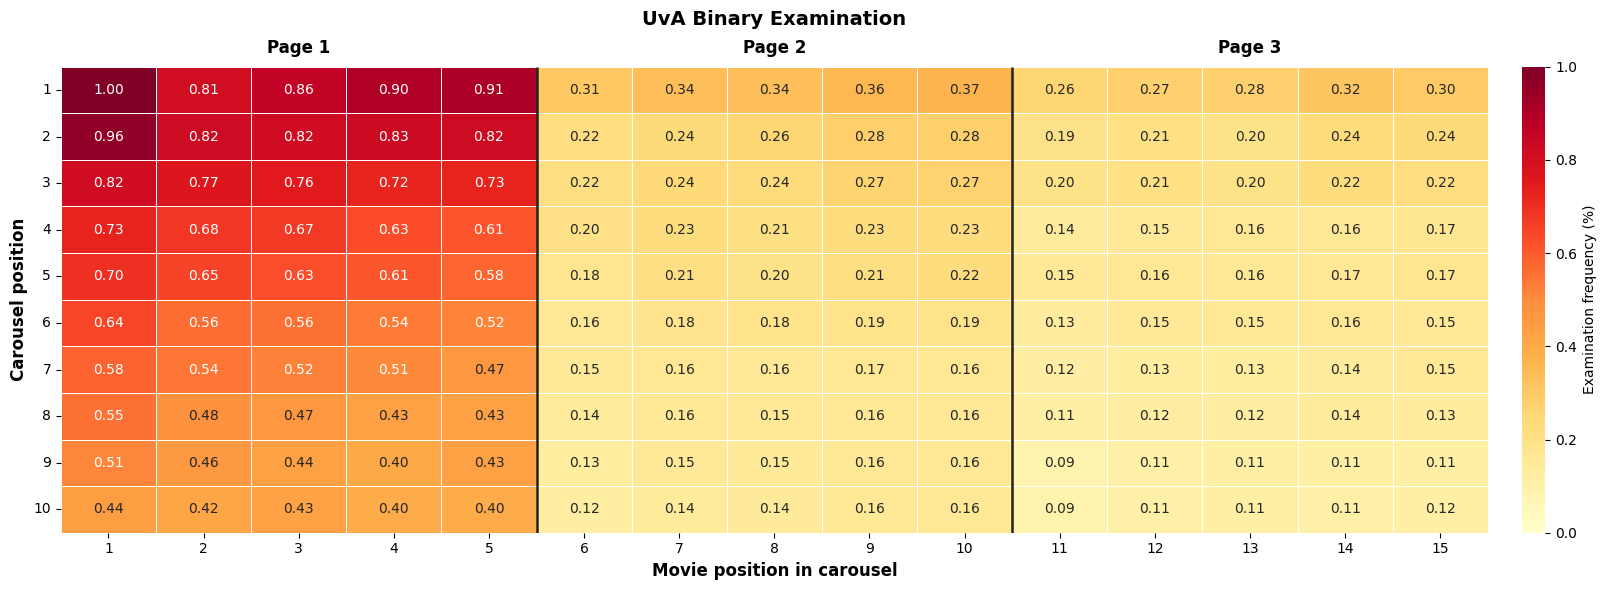

In [37]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pivot_df = binary_exam_result_UvA.pivot(
    index="Fixation_AOI_Carousel_position",
    columns="Fixation_AOI_Movie_position_in_carousel",
    values="exam_freq"
)

fig, ax = plt.subplots(figsize=(18, 6))

hm = sns.heatmap(
    pivot_df,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,   # ← legend 上限
    linewidths=0.4,      # 细网格线
    linecolor="white",
    cbar_kws={
        "label": "Examination frequency (%)",
        "pad": 0.02      # ← 关键：调小这里
    },
    ax=ax
)


ax.set_title("UvA Binary Examination", fontsize=14, fontweight="bold", pad=30)
ax.set_xlabel("Movie position in carousel", fontsize=12,
        fontweight="bold")
ax.set_ylabel("Carousel position", fontsize=12,
        fontweight="bold")

# x ticks：title + 1..15
n_cols = len(pivot_df.columns)
xticks = np.arange(n_cols) + 0.5
xlabels = list(range(1, 16))
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, rotation=0)

# y ticks：显示为整数 1..10（去掉 .0）
n_rows = pivot_df.shape[0]
yticks = np.arange(n_rows) + 0.5
ylabels = list(range(1, n_rows + 1))
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, rotation=0)

# --- Vertical separator lines (page boundaries) ---
for x in [5, 10]:
    ax.vlines(x, *ax.get_ylim(), colors="#222222", linewidth=1.8)

# --- Group labels ---
group_centers = {"Page 1": 2.5, "Page 2": 7.5, "Page 3": 12.5}
for label, col_center in group_centers.items():
    ax.text(
        col_center / n_cols,
        1.02,
        label,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )


plt.tight_layout()
plt.savefig("Examination.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

In [38]:
stats = df.groupby([user_col, task_col, x_col, y_col]).size().reset_index(name='n_visits')
each_carousel = stats.groupby([x_col, user_col, task_col]).size().reset_index().groupby([x_col])[[user_col, task_col]].size().reset_index(name="exam_row")
binary_exam_result = stats.groupby([x_col, y_col]).size().reset_index(name='n_users_tasks')
n_pairs = stats.groupby([user_col, task_col]).size().shape[0]
binary_exam_result['exam_freq'] = binary_exam_result['n_users_tasks'] / n_pairs * 100
binary_exam_result = binary_exam_result.merge(each_carousel, on = ['Fixation_AOI_Carousel_position'], how='left')
binary_exam_result["inner_freq"] = binary_exam_result["n_users_tasks"] / binary_exam_result["exam_row"] * 100
binary_exam_result = binary_exam_result[binary_exam_result['Fixation_AOI_Movie_position_in_carousel'] !=0]
binary_exam_result['exam_freq'] = binary_exam_result['exam_freq'] / binary_exam_result['exam_freq'].max()

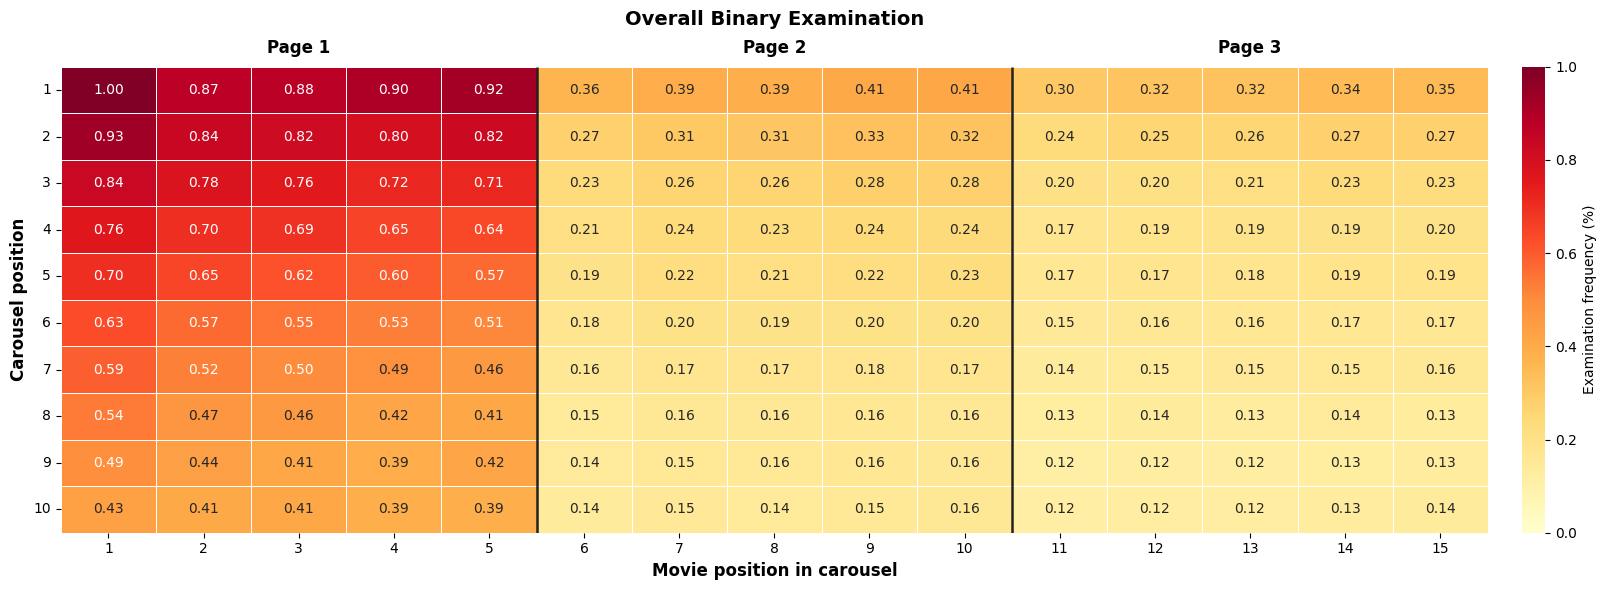

In [39]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pivot_df = binary_exam_result.pivot(
    index="Fixation_AOI_Carousel_position",
    columns="Fixation_AOI_Movie_position_in_carousel",
    values="exam_freq"
)

fig, ax = plt.subplots(figsize=(18, 6))

hm = sns.heatmap(
    pivot_df,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,   # ← legend 上限
    linewidths=0.4,      # 细网格线
    linecolor="white",
    cbar_kws={
        "label": "Examination frequency (%)",
        "pad": 0.02      # ← 关键：调小这里
    },
    ax=ax
)


ax.set_title("Overall Binary Examination", fontsize=14, fontweight="bold", pad=30)
ax.set_xlabel("Movie position in carousel", fontsize=12,
        fontweight="bold")
ax.set_ylabel("Carousel position", fontsize=12,
        fontweight="bold")

# x ticks：title + 1..15
n_cols = len(pivot_df.columns)
xticks = np.arange(n_cols) + 0.5
xlabels = list(range(1, 16))
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, rotation=0)

# y ticks：显示为整数 1..10（去掉 .0）
n_rows = pivot_df.shape[0]
yticks = np.arange(n_rows) + 0.5
ylabels = list(range(1, n_rows + 1))
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, rotation=0)

# --- Vertical separator lines (page boundaries) ---
for x in [5, 10]:
    ax.vlines(x, *ax.get_ylim(), colors="#222222", linewidth=1.8)

# --- Group labels ---
group_centers = {"Page 1": 2.5, "Page 2": 7.5, "Page 3": 12.5}
for label, col_center in group_centers.items():
    ax.text(
        col_center / n_cols,
        1.02,
        label,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )


plt.tight_layout()
plt.savefig("Examination.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

# discount value

## original N2DCG

### naive GT

In [40]:
import numpy as np
from scipy.stats import spearmanr, pearsonr

rows = binary_exam_result_KINIT["Fixation_AOI_Carousel_position"].values
cols = binary_exam_result_KINIT["Fixation_AOI_Movie_position_in_carousel"].values
freq = binary_exam_result_KINIT["exam_freq"].values / binary_exam_result_KINIT["exam_freq"].values.max()

print("Naive Golden Triangle: 1/log2(α*row + β*col)")

results = []
for alpha in range(1, 11):
    for beta in range(1, 11):
        val = alpha * rows + beta * cols
        if np.any(val <= 1):
            continue
        pred = 1 / np.log2(val)
        pred = pred / pred.max()
        rho, _ = spearmanr(freq, pred)
        r,   _ = pearsonr(freq, pred)
        results.append((alpha, beta, rho, r))

results.sort(key=lambda x: (-x[2], -x[3]))

print(f"\n{'α':>3} {'β':>3}  {'Spearman':>10} {'Pearson':>10}")
print("-" * 20)
for a, b, rho, r in results[:10]:
    print(f"  α={a}, β={b}  →  ρ = {rho:.4f} r = {r:.4f}")

Naive Golden Triangle: 1/log2(α*row + β*col)

  α   β    Spearman    Pearson
--------------------
  α=7, β=6  →  ρ = 0.9048 r = 0.8906
  α=10, β=9  →  ρ = 0.9047 r = 0.8970
  α=8, β=7  →  ρ = 0.9047 r = 0.8933
  α=6, β=5  →  ρ = 0.9047 r = 0.8869
  α=9, β=8  →  ρ = 0.9046 r = 0.8954
  α=10, β=8  →  ρ = 0.9033 r = 0.8899
  α=5, β=4  →  ρ = 0.9033 r = 0.8814
  α=10, β=10  →  ρ = 0.9024 r = 0.9016
  α=9, β=9  →  ρ = 0.9024 r = 0.9007
  α=8, β=8  →  ρ = 0.9024 r = 0.8996


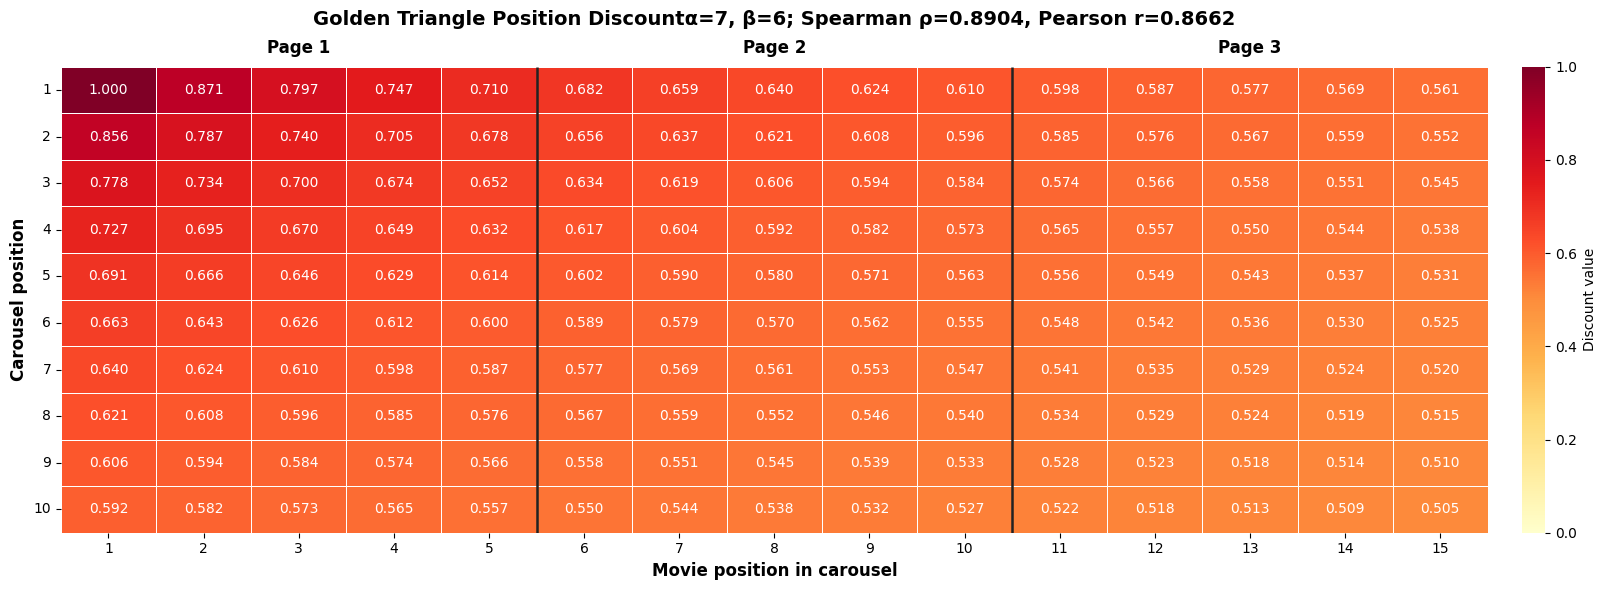

In [41]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Grid dimensions ---
n_rows = 10
n_cols = 15
alpha = 7
beta = 6

# --- Compute Golden Triangle discount ---
discount = np.zeros((n_rows, n_cols))
for i in range(n_rows):
    for j in range(n_cols):
        row_pos = i + 1  # 1-indexed
        col_pos = j + 1  # 1-indexed
        discount[i, j] = 1 / np.log2(alpha * row_pos + beta * col_pos)

discount = discount / discount.max()

# --- Build DataFrame ---
col_labels = list(range(1, n_cols + 1))
row_labels = list(range(1, n_rows + 1))
df = pd.DataFrame(discount, index=row_labels, columns=col_labels)

# --- Plot ---
fig, ax = plt.subplots(figsize=(18, 6))

hm = sns.heatmap(
    df,
    cmap="YlOrRd",
    annot=True,
    fmt=".3f",
    vmin=0,
    vmax=1.0,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={
        "label": "Discount value",
        "pad": 0.02
    },
    ax=ax
)


ax.set_xlabel("Movie position in carousel", fontsize=12, fontweight="bold")
ax.set_ylabel("Carousel position", fontsize=12, fontweight="bold")

# x ticks
xticks = np.arange(n_cols) + 0.5
ax.set_xticks(xticks)
ax.set_xticklabels(col_labels, rotation=0)

# y ticks
yticks = np.arange(n_rows) + 0.5
ax.set_yticks(yticks)
ax.set_yticklabels(row_labels, rotation=0)

# --- Page boundaries ---
for x in [5, 10]:
    ax.vlines(x, *ax.get_ylim(), colors="#222222", linewidth=1.8)

# --- Group labels ---
group_centers = {"Page 1": 2.5, "Page 2": 7.5, "Page 3": 12.5}
for label, col_center in group_centers.items():
    ax.text(
        col_center / n_cols,
        1.02,
        label,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

rows = []
for i in range(n_rows):
    for j in range(n_cols):
        rows.append({
            'Fixation_AOI_Carousel_position': i + 1,
            'Fixation_AOI_Movie_position_in_carousel': j + 1,
            'discount': discount[i, j]
        })

discount_df_2 = pd.DataFrame(rows)

freq = binary_exam_result_UvA['exam_freq'].reset_index(drop=True) / binary_exam_result_UvA['exam_freq'].reset_index(drop=True).max()


rho = freq.corr(discount_df_2['discount'].reset_index(drop=True), method='spearman')
r = freq.corr(discount_df_2['discount'].reset_index(drop=True), method='pearson')
ax.set_title(
    f"Golden Triangle Position Discount"
    f"α={alpha}, β={beta}; Spearman ρ={rho:.4f}, Pearson r={r:.4f}",
    fontsize=14,
    fontweight="bold",
    pad=30
)

plt.tight_layout()
plt.savefig("golden_triangle_discount.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

### naive GT + user actions

In [42]:
import numpy as np
from scipy.stats import spearmanr
from itertools import product

rows = binary_exam_result_KINIT["Fixation_AOI_Carousel_position"].values
cols = binary_exam_result_KINIT["Fixation_AOI_Movie_position_in_carousel"].values
freq = binary_exam_result_KINIT["exam_freq"].values / binary_exam_result_KINIT["exam_freq"].values.max()

Vh, dh = 5, 5
Vv, dv = 3, 1

# 预计算 nh, nv（不随参数变化）
nh = np.maximum(0, np.ceil((cols - Vh) / dh))
nv = np.maximum(0, np.ceil((rows - Vv) / dv))

print("Naive GT + User Actions: 1/log2(α·row + β·col + γ·nh + λ·nv)")
print(f"\n{'α':>3} {'β':>3} {'γ':>3} {'λ':>3}  {'ρ':>8}")
print("-" * 28)

results = []
for alpha, beta, gamma, lam in product(range(1, 11), range(1, 11), range(1, 11), range(1, 11)):
    val = alpha*rows + beta*cols + gamma*nh + lam*nv
    if np.any(val <= 1):
        continue
    pred = 1 / np.log2(val)
    pred = pred / pred.max()
    rho, _ = spearmanr(freq, pred)
    r,   _ = pearsonr(freq, pred)
    results.append((alpha, beta, gamma, lam, rho, r))

results.sort(key=lambda x: (-x[4], -x[5]))

for a, b, g, l, rho, r in results[:10]:
    print(f"{a:>3} {b:>3} {g:>3} {l:>3}  {rho:>8.4f} {r:>8.4f}")

Naive GT + User Actions: 1/log2(α·row + β·col + γ·nh + λ·nv)

  α   β   γ   λ         ρ
----------------------------
  2   1   9   1    0.9349   0.8745
  2   1  10   1    0.9347   0.8784
  2   1   8   1    0.9339   0.8700
  2   1   7   1    0.9308   0.8647
  1   1   9   2    0.9307   0.8185
  1   1   8   2    0.9305   0.8147
  3   1  10   1    0.9304   0.8760
  2   1  10   2    0.9302   0.8610
  1   1  10   2    0.9300   0.8219
  3   2  10   1    0.9293   0.9029


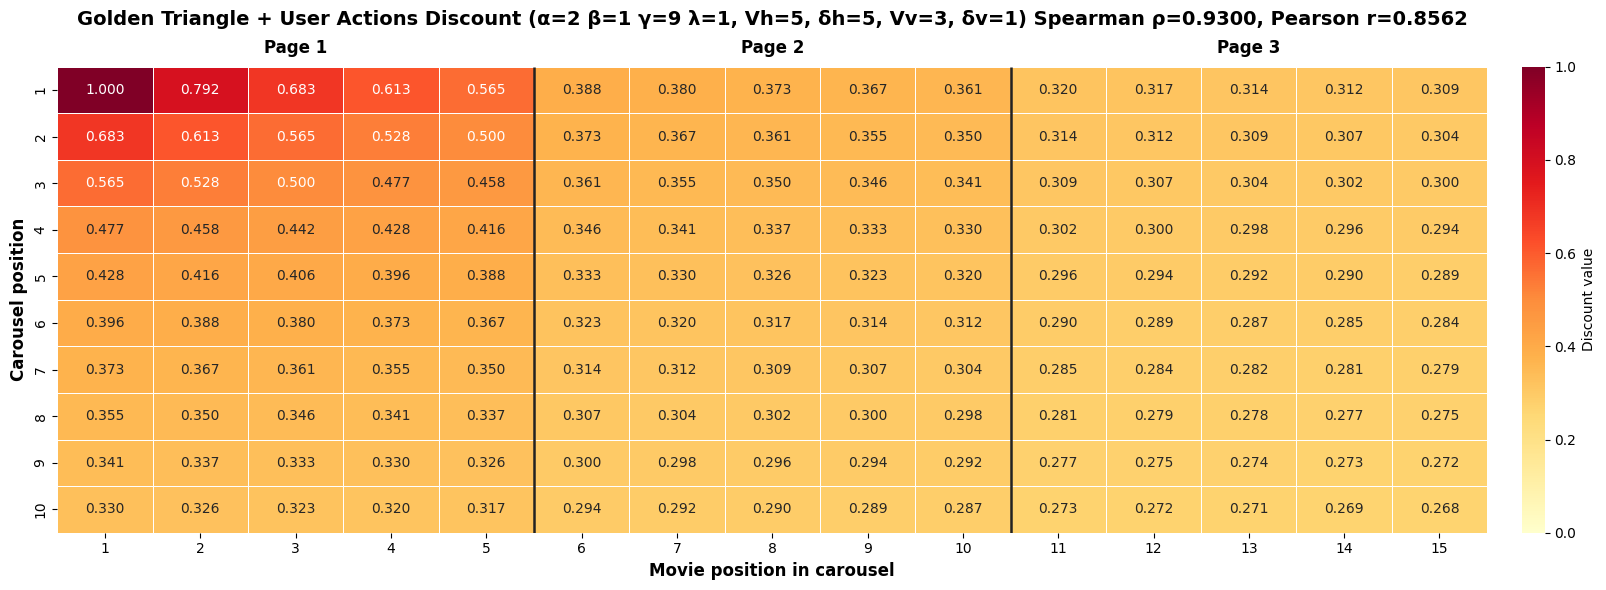

In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

n_rows, n_cols = 10, 15
Vh, dh = 5, 5
Vv, dv = 3, 1

α=2
β=1
γ=9
λ=1

g = np.zeros((n_rows, n_cols))
for i in range(n_rows):
    for j in range(n_cols):
        nh = max(0, np.ceil(((j+1) - Vh) / dh))
        nv = max(0, np.ceil(((i+1) - Vv) / dv))
        g[i, j] = 1 / np.log2(α * (i+1) + β * (j+1) + γ * nh + λ * nv)

g = g/g.max()

df = pd.DataFrame(g, index=range(1,11), columns=range(1,16))

fig, ax = plt.subplots(figsize=(18, 6))

sns.heatmap(df, cmap="YlOrRd", annot=True, fmt=".3f",
            vmin=0, vmax=1.0, linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Discount value", "pad": 0.02}, ax=ax)


ax.set_xlabel("Movie position in carousel", fontsize=12, fontweight="bold")
ax.set_ylabel("Carousel position", fontsize=12, fontweight="bold")

for x in [5, 10]:
    ax.vlines(x, *ax.get_ylim(), colors="#222222", linewidth=1.8)

for label, cc in {"Page 1": 2.5, "Page 2": 7.5, "Page 3": 12.5}.items():
    ax.text(cc/15, 1.02, label, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=12, fontweight="bold")

rows = []
for i in range(n_rows):
    for j in range(n_cols):
        rows.append({
            'Fixation_AOI_Carousel_position': i + 1,
            'Fixation_AOI_Movie_position_in_carousel': j + 1,
            'discount': g[i, j]
        })

discount_df_3 = pd.DataFrame(rows)

freq = binary_exam_result_UvA['exam_freq'].reset_index(drop=True) / binary_exam_result_UvA['exam_freq'].reset_index(drop=True).max()


rho = freq.corr(discount_df_3['discount'].reset_index(drop=True), method='spearman')
r = freq.corr(discount_df_3['discount'].reset_index(drop=True), method='pearson')

ax.set_title(f"Golden Triangle + User Actions Discount (α={α} β={β} γ={γ} λ={λ}, Vh=5, δh=5, Vv=3, δv=1) Spearman ρ={rho:.4f}, Pearson r={r:.4f}", fontsize=14, fontweight="bold", pad=30)

plt.tight_layout()
plt.savefig("user_actions_discount.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

## reversed

In [44]:
import numpy as np
from scipy.stats import spearmanr

rows = binary_exam_result_KINIT["Fixation_AOI_Carousel_position"].values
cols = binary_exam_result_KINIT["Fixation_AOI_Movie_position_in_carousel"].values
freq = binary_exam_result_KINIT["exam_freq"].values / binary_exam_result_KINIT["exam_freq"].values.max()

page_size = 5
Vh, dh = 5, 5
Vv, dv = 3, 1

effective_k = np.zeros_like(cols)
for idx, c in enumerate(cols):
    page = int(np.ceil(c / page_size))
    k_local = c - (page - 1) * page_size
    if page == 1:
        effective_k[idx] = k_local
    else:
        effective_k[idx] = page * page_size - k_local + 1

nh = np.maximum(0, np.ceil((cols - Vh) / dh))
nv = np.maximum(0, np.ceil((rows - Vv) / dv))

# --- 测试你最好的模型：Reversed GT + User Actions ---
print("Reversed GT + User Actions: 1/log2(α*i + β*ek + γ*nh + λ*nv)")
print(f"{'α':>3} {'β':>3} {'γ':>3} {'λ':>3}  {'ρ':>8}")
print("-" * 30)

results = []
for alpha, beta, gamma, lam in product(range(1, 11), range(1, 11), range(1, 11), range(1, 11)):
    val = alpha*rows + beta*effective_k + gamma*nh + lam*nv
    if np.any(val <= 1):
        continue
    pred = 1 / np.log2(val)
    pred = pred / pred.max()
    rho, _ = spearmanr(freq, pred)
    r,   _ = pearsonr(freq, pred)
    results.append((alpha, beta, gamma, lam, rho, r))

results.sort(key=lambda x: (-x[4], -x[5]))

for a, b, g, l, rho, r in results[:10]:
    print(f"{a:>3} {b:>3} {g:>3} {l:>3}  {rho:>8.4f} {r:>8.4f}")

# --- 也测 Reversed GT (no actions) ---
print("\n\nReversed GT (no actions): 1/log2(α*i + β*ek)")
print("\nTop 10:")

results2 = []
for alpha in range(1,11):
    for beta in range(1,11):
        val = alpha*rows + beta*effective_k
        if np.any(val <= 1):
            continue
        pred = 1 / np.log2(val)
        pred = pred / pred.max()
        rho, _ = spearmanr(freq, pred)
        r,   _ = pearsonr(freq, pred)
        results2.append((alpha, beta, rho, r))

results2.sort(key=lambda x: (-x[2], -x[3]))

for a, b, rho, r in results2[:10]:
    print(f"  α={a}, β={b}  →  {rho:>8.4f} {r:>8.4f}")

Reversed GT + User Actions: 1/log2(α*i + β*ek + γ*nh + λ*nv)
  α   β   γ   λ         ρ
------------------------------
  2   1   9   1    0.9461   0.8766
  2   1  10   1    0.9456   0.8804
  2   1   8   1    0.9456   0.8723
  3   2   9   1    0.9450   0.9032
  3   2  10   1    0.9449   0.9064
  3   2   8   1    0.9446   0.8995
  4   3  10   1    0.9438   0.9138
  4   3   9   1    0.9438   0.9110
  5   3  10   1    0.9434   0.9062
  3   2   7   1    0.9433   0.8953


Reversed GT (no actions): 1/log2(α*i + β*ek)

Top 10:
  α=10, β=9  →    0.9332   0.9056
  α=9, β=8  →    0.9330   0.9039
  α=8, β=7  →    0.9329   0.9018
  α=7, β=6  →    0.9326   0.8990
  α=10, β=10  →    0.9322   0.9104
  α=9, β=9  →    0.9322   0.9094
  α=8, β=8  →    0.9322   0.9082
  α=7, β=7  →    0.9322   0.9067
  α=6, β=6  →    0.9322   0.9048
  α=5, β=5  →    0.9322   0.9021


### Reversed GT

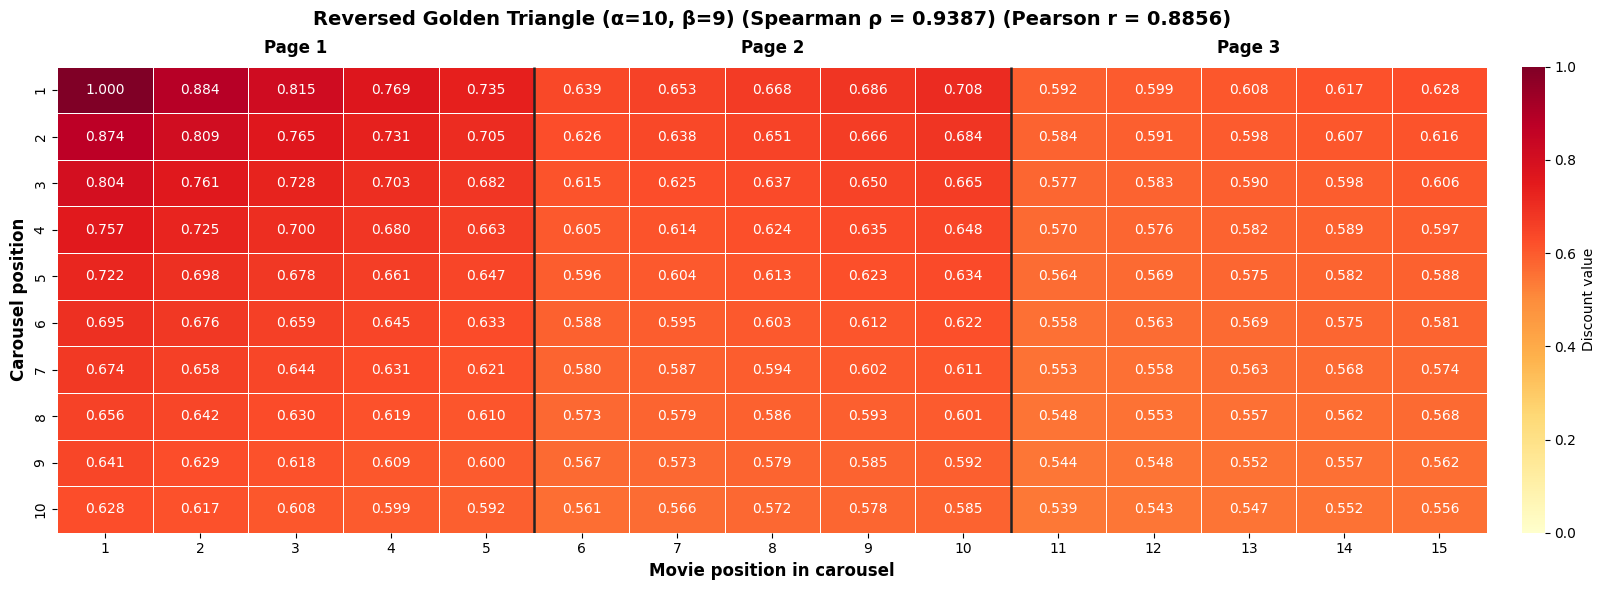

In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

n_rows, n_cols = 10, 15
page_size = 5

α=10
β=9

g = np.zeros((n_rows, n_cols))
for i in range(n_rows):
    for j in range(n_cols):
        row = i + 1
        col = j + 1

        page = int(np.ceil(col / page_size))
        k_local = col - (page - 1) * page_size

        if page == 1:
            effective_k = k_local
        else:
            effective_k = page * page_size - k_local + 1

        g[i, j] = 1 / np.log2(α * row + β * effective_k)

g = g/g.max()

df = pd.DataFrame(g, index=range(1, 11), columns=range(1, 16))

fig, ax = plt.subplots(figsize=(18, 6))

sns.heatmap(df, cmap="YlOrRd", annot=True, fmt=".3f",
            vmin=0, vmax=1.0, linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Discount value", "pad": 0.02}, ax=ax)



rows = []
for i in range(n_rows):
    for j in range(n_cols):
        rows.append({
            'Fixation_AOI_Carousel_position': i + 1,
            'Fixation_AOI_Movie_position_in_carousel': j + 1,
            'discount': g[i, j]
        })

discount_df_5 = pd.DataFrame(rows)

freq = binary_exam_result_UvA['exam_freq'].reset_index(drop=True) / binary_exam_result_UvA['exam_freq'].reset_index(drop=True).max()


rho = freq.corr(discount_df_5['discount'].reset_index(drop=True), method='spearman')
r = freq.corr(discount_df_5['discount'].reset_index(drop=True), method='pearson')

ax.set_title(f"Reversed Golden Triangle (α=10, β=9) (Spearman ρ = {rho:.4f}) (Pearson r = {r:.4f})", fontsize=14, fontweight="bold", pad=30)
ax.set_xlabel("Movie position in carousel", fontsize=12, fontweight="bold")
ax.set_ylabel("Carousel position", fontsize=12, fontweight="bold")

for x in [5, 10]:
    ax.vlines(x, *ax.get_ylim(), colors="#222222", linewidth=1.8)

for label, cc in {"Page 1": 2.5, "Page 2": 7.5, "Page 3": 12.5}.items():
    ax.text(cc / 15, 1.02, label, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("reversed_golden_triangle_no_actions.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

### Reversed GT + User Actions

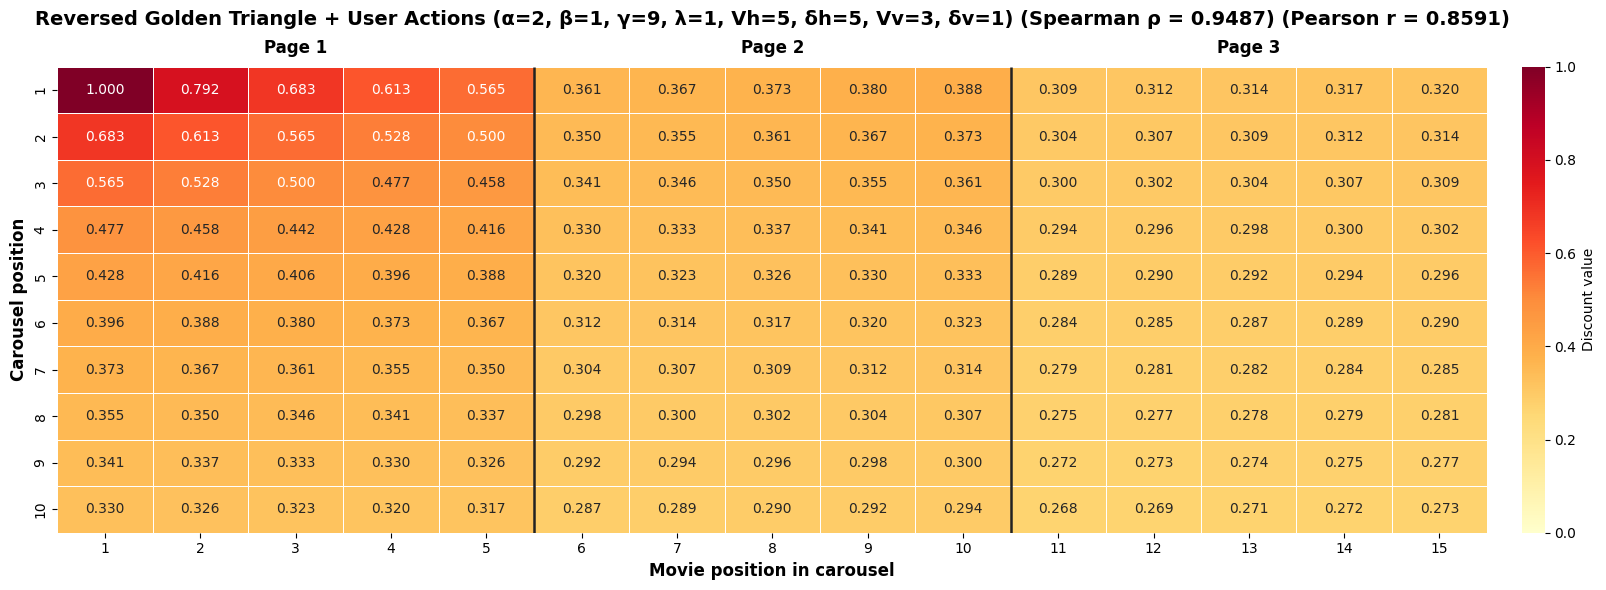

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

n_rows, n_cols = 10, 15
page_size = 5
Vh, dh = 5, 5
Vv, dv = 3, 1
α=2
β=1
γ=9
λ=1

g = np.zeros((n_rows, n_cols))
for i in range(n_rows):
    for j in range(n_cols):
        row = i + 1
        col = j + 1

        page = int(np.ceil(col / page_size))       # 1, 2, 3
        k_local = col - (page - 1) * page_size      # 1..5 within page

        if page == 1:
            effective_k = k_local                    # 左→右递减: 1,2,3,4,5
        else:
            effective_k = page * page_size - k_local + 1

        # swipe penalties
        nh = max(0, np.ceil((col - Vh) / dh))
        nv = max(0, np.ceil((row - Vv) / dv))

        g[i, j] = 1 / np.log2(α * row + β * effective_k + γ * nh + λ * nv)

g = g/g.max()
df = pd.DataFrame(g, index=range(1, 11), columns=range(1, 16))

fig, ax = plt.subplots(figsize=(18, 6))

sns.heatmap(df, cmap="YlOrRd", annot=True, fmt=".3f",
            vmin=0, vmax=1.0, linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Discount value", "pad": 0.02}, ax=ax)


ax.set_xlabel("Movie position in carousel", fontsize=12, fontweight="bold")
ax.set_ylabel("Carousel position", fontsize=12, fontweight="bold")

for x in [5, 10]:
    ax.vlines(x, *ax.get_ylim(), colors="#222222", linewidth=1.8)

for label, cc in {"Page 1": 2.5, "Page 2": 7.5, "Page 3": 12.5}.items():
    ax.text(cc / 15, 1.02, label, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=12, fontweight="bold")


rows = []
for i in range(n_rows):
    for j in range(n_cols):
        rows.append({
            'Fixation_AOI_Carousel_position': i + 1,
            'Fixation_AOI_Movie_position_in_carousel': j + 1,
            'discount': g[i, j]
        })

discount_df_4 = pd.DataFrame(rows)

freq = binary_exam_result_UvA['exam_freq'].reset_index(drop=True) / binary_exam_result_UvA['exam_freq'].reset_index(drop=True).max()


rho = freq.corr(discount_df_4['discount'].reset_index(drop=True), method='spearman')
r = freq.corr(discount_df_4['discount'].reset_index(drop=True), method='pearson')

ax.set_title(f"Reversed Golden Triangle + User Actions (α={α}, β={β}, γ={γ}, λ={λ}, Vh=5, δh=5, Vv=3, δv=1) (Spearman ρ = {rho:.4f}) (Pearson r = {r:.4f})", fontsize=14, fontweight="bold", pad=30)


plt.tight_layout()
plt.savefig("reversed_golden_triangle.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

### Reversed GT x User Actions

In [47]:
import numpy as np
from scipy.stats import rankdata
from itertools import product

rows = binary_exam_result_KINIT["Fixation_AOI_Carousel_position"].values
cols = binary_exam_result_KINIT["Fixation_AOI_Movie_position_in_carousel"].values
freq = binary_exam_result_KINIT["exam_freq"].values / binary_exam_result_KINIT["exam_freq"].values.max()

page_size = 5
Vh, dh = 5, 5
Vv, dv = 3, 1

# --- 预计算 ---
effective_k = np.zeros_like(cols, dtype=float)
for idx, c in enumerate(cols):
    page = int(np.ceil(c / page_size))
    k_local = c - (page - 1) * page_size
    effective_k[idx] = k_local if page == 1 else page * page_size - k_local + 1


nh = np.maximum(0, np.ceil((cols - Vh) / dh))     # 水平 swipe 次数 (0/1/2)
nv = np.maximum(0, np.ceil((rows - Vv) / dv))

# --- 四参数网格：α, β, ρ_c, ρ_r ---
alpha_grid = range(1, 11)
beta_grid  = range(1, 11)
rho_c_grid = np.arange(0.05, 1.00, 0.05)   # 每次水平 swipe 的几何衰减
rho_r_grid = np.arange(0.05, 1.00, 0.05)   # 每次垂直 swipe 的几何衰减


results = []
for alpha, beta in product(alpha_grid, beta_grid):
    val = alpha * rows + beta * effective_k
    if np.any(val <= 1):
        continue
    for γ in rho_c_grid:
        γ_pow = γ ** nh
        for λ in rho_r_grid:
            pred = (1 / np.log2(val)) * γ_pow * (λ ** nv)
            pred = pred / pred.max()
            rho, _ = spearmanr(freq, pred)
            r,   _ = pearsonr(freq, pred)
            results.append((alpha, beta, γ, λ, rho, r))

results.sort(key=lambda x: (-x[4],-x[5]))

print(f"{'α':>3} {'β':>3} {'ρ_c':>6} {'ρ_r':>6}  {'spear':>8} {'pearson':>8}")
print("-" * 36)
for a, b, rc, rr, s, r in results[:10]:
    print(f"{a:>3} {b:>3} {rc:>6.2f} {rr:>6.2f}  {s:>8.4f} {r:>8.4f}")

  α   β    ρ_c    ρ_r     spear  pearson
------------------------------------
  1   9   0.90   0.95    0.9542   0.9244
  1  10   0.90   0.95    0.9542   0.9244
  1   8   0.90   0.95    0.9539   0.9244
  1   7   0.90   0.95    0.9537   0.9244
  1   5   0.90   0.95    0.9536   0.9236
  2  10   0.90   0.95    0.9535   0.9319
  1   6   0.90   0.95    0.9533   0.9242
  1   4   0.90   0.95    0.9530   0.9220
  2   9   0.90   0.95    0.9529   0.9319
  2   8   0.90   0.95    0.9523   0.9316


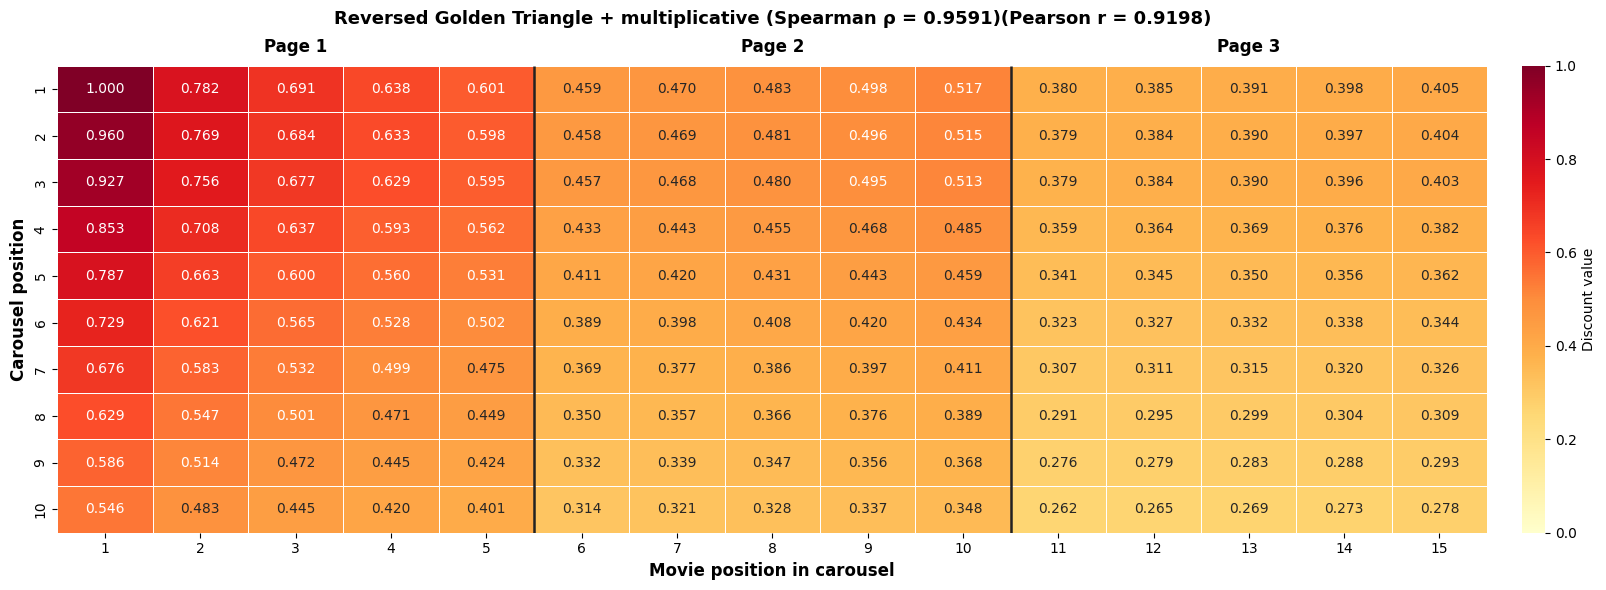

In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# -----------------------------------------------------------------------------
# Grid dimensions
# -----------------------------------------------------------------------------
n_rows, n_cols = 10, 15      # 10 carousels x 15 movie slots (3 pages x 5/page)
page_size      = 5           # 5 movies per page
Vh, dh = 5, 5
Vv, dv = 3, 1


# -----------------------------------------------------------------------------
# Model parameters (from grid search)
# -----------------------------------------------------------------------------
α  = 1       # ← 填入最佳 α
β  = 9       # ← 填入最佳 β
rho_c = 0.9
rho_r = 0.95


g = np.zeros((n_rows, n_cols))
for i in range(n_rows):
    for j in range(n_cols):
        row = i + 1          # carousel position (1..10)
        col = j + 1          # movie position    (1..15)

        # ---------------------------------------------------------------------
        # Step 1: Locate the page and the within-page column index.
        # ---------------------------------------------------------------------
        page    = int(np.ceil(col / page_size))             # 1, 2, or 3
        k_local = col - (page - 1) * page_size              # 1..5 within page

        nh = max(0, np.ceil((col - Vh) / dh))
        nv = max(0, np.ceil((row - Vv) / dv))

        # ---------------------------------------------------------------------
        # Step 2: Compute effective_k (anchor reversal across pages).
        # ---------------------------------------------------------------------
        # Page 1: anchor on the left; cost increases left-to-right.
        #         eff_k = 1, 2, 3, 4, 5
        # Page 2: anchor on the right (k=10); cost increases right-to-left.
        #         eff_k = 10, 9, 8, 7, 6
        # Page 3: anchor on the right (k=15).
        #         eff_k = 15, 14, 13, 12, 11
        if page == 1:
            effective_k = k_local
        else:
            effective_k = page * page_size - k_local + 1


        # Step 5
        g[i, j] = (1 / np.log2(α * row + β * effective_k)) * (rho_c ** nh) * (rho_r ** nv)

g =g/g.max()

df = pd.DataFrame(g, index=range(1, 11), columns=range(1, 16))

fig, ax = plt.subplots(figsize=(18, 6))

sns.heatmap(df, cmap="YlOrRd", annot=True, fmt=".3f",
            vmin=0, vmax=1.0, linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Discount value", "pad": 0.02}, ax=ax)


ax.set_xlabel("Movie position in carousel", fontsize=12, fontweight="bold")
ax.set_ylabel("Carousel position", fontsize=12, fontweight="bold")

for x in [5, 10]:
    ax.vlines(x, *ax.get_ylim(), colors="#222222", linewidth=1.8)

for label, cc in {"Page 1": 2.5, "Page 2": 7.5, "Page 3": 12.5}.items():
    ax.text(cc / 15, 1.02, label, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=12, fontweight="bold")


rows = []
for i in range(n_rows):
    for j in range(n_cols):
        rows.append({
            'Fixation_AOI_Carousel_position': i + 1,
            'Fixation_AOI_Movie_position_in_carousel': j + 1,
            'discount': g[i, j]
        })

discount_df_6 = pd.DataFrame(rows)

freq = binary_exam_result_UvA['exam_freq'].reset_index(drop=True) / binary_exam_result_UvA['exam_freq'].reset_index(drop=True).max()


rho = freq.corr(discount_df_6['discount'].reset_index(drop=True), method='spearman')
r = freq.corr(discount_df_6['discount'].reset_index(drop=True), method='pearson')

ax.set_title(
    f"Reversed Golden Triangle + multiplicative "
    f"(Spearman ρ = {rho:.4f})"
    f"(Pearson r = {r:.4f})",
    fontsize=13, fontweight="bold", pad=30
)

plt.tight_layout()
plt.savefig("reversed_golden_triangle_multiplicative.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

### Reversed GT x row-page

In [49]:
import numpy as np
from scipy.stats import rankdata
from itertools import product

rows = binary_exam_result_KINIT["Fixation_AOI_Carousel_position"].values
cols = binary_exam_result_KINIT["Fixation_AOI_Movie_position_in_carousel"].values
freq = binary_exam_result_KINIT["exam_freq"].values / binary_exam_result_KINIT["exam_freq"].values.max()

page_size = 5

# --- 预计算 ---
pages = np.ceil(cols / page_size).astype(int)        # 每个样本所在 page (1/2/3)

effective_k = np.zeros_like(cols, dtype=float)
for idx, c in enumerate(cols):
    page = pages[idx]
    k_local = c - (page - 1) * page_size
    effective_k[idx] = k_local if page == 1 else page * page_size - k_local + 1

nv = np.ceil(rows-1)


mask_p2 = (pages == 2)
mask_p3 = (pages == 3)

# --- 预计算 freq 的中心化版本，用于 Pearson ---
freq_centered = freq - freq.mean()
freq_norm = np.sqrt(np.sum(freq_centered ** 2))

# --- 预计算 freq rank，用于 Spearman ---
freq_rank = rankdata(freq)
freq_rank_centered = freq_rank - freq_rank.mean()
freq_rank_norm = np.sqrt(np.sum(freq_rank_centered ** 2))

def fast_corr(x_centered, x_norm, y):
    """
    计算 Pearson correlation。
    x_centered 和 x_norm 是预计算好的。
    """
    y_centered = y - y.mean()
    y_norm = np.sqrt(np.sum(y_centered ** 2))

    if y_norm == 0 or x_norm == 0:
        return np.nan

    return np.sum(x_centered * y_centered) / (x_norm * y_norm)


# --- 五参数网格 ---
alpha_grid = range(1, 11)
beta_grid  = range(1, 11)
mu_grid    = np.arange(0.05, 1.00, 0.05)
rho_grid  = np.arange(0.05, 1.00, 0.05)


results = []
for alpha, beta, mu, rho in product(
        alpha_grid, beta_grid, mu_grid, rho_grid):

    val = alpha * rows + beta * effective_k
    if np.any(val <= 1):
        continue

    # 按 page 查表赋折扣
    h_discount = np.ones_like(cols, dtype=float)
    h_discount[mask_p2] = rho
    h_discount[mask_p3] = rho

    pred = (1 / np.log2(val)) * h_discount * (mu ** nv)
    pred = pred / pred.max()

    # Pearson
    pearson = fast_corr(freq_centered, freq_norm, pred)

    # Spearman = Pearson(rank(freq), rank(pred))
    pred_rank = rankdata(pred)
    spear = fast_corr(freq_rank_centered, freq_rank_norm, pred_rank)

    results.append((alpha, beta, mu, rho, spear, pearson))

results.sort(key=lambda x: (-x[4], -x[5]))

print(f"{'α':>3} {'β':>3} {'ρ_r':>6} {'ρ':>6} {'spear':>8} {'pearson':>8}")
print("-" * 44)
for a, b, m, r, c, p in results[:10]:
    print(f"{a:>3} {b:>3} {m:>6.2f} {r:>6.2f}  {c:>8.4f} {p:>8.4f}")

  α   β    ρ_r      ρ    spear  pearson
--------------------------------------------
  4   9   0.95   0.65    0.9940   0.9833
  4   8   0.95   0.65    0.9940   0.9827
  5  10   0.95   0.65    0.9939   0.9845
  3   7   0.95   0.65    0.9939   0.9805
  3   8   0.95   0.65    0.9939   0.9811
  4  10   0.95   0.65    0.9939   0.9837
  2   4   0.95   0.65    0.9939   0.9725
  3   6   0.95   0.65    0.9939   0.9795
  4   7   0.95   0.65    0.9939   0.9817
  1   1   0.95   0.55    0.9939   0.9123


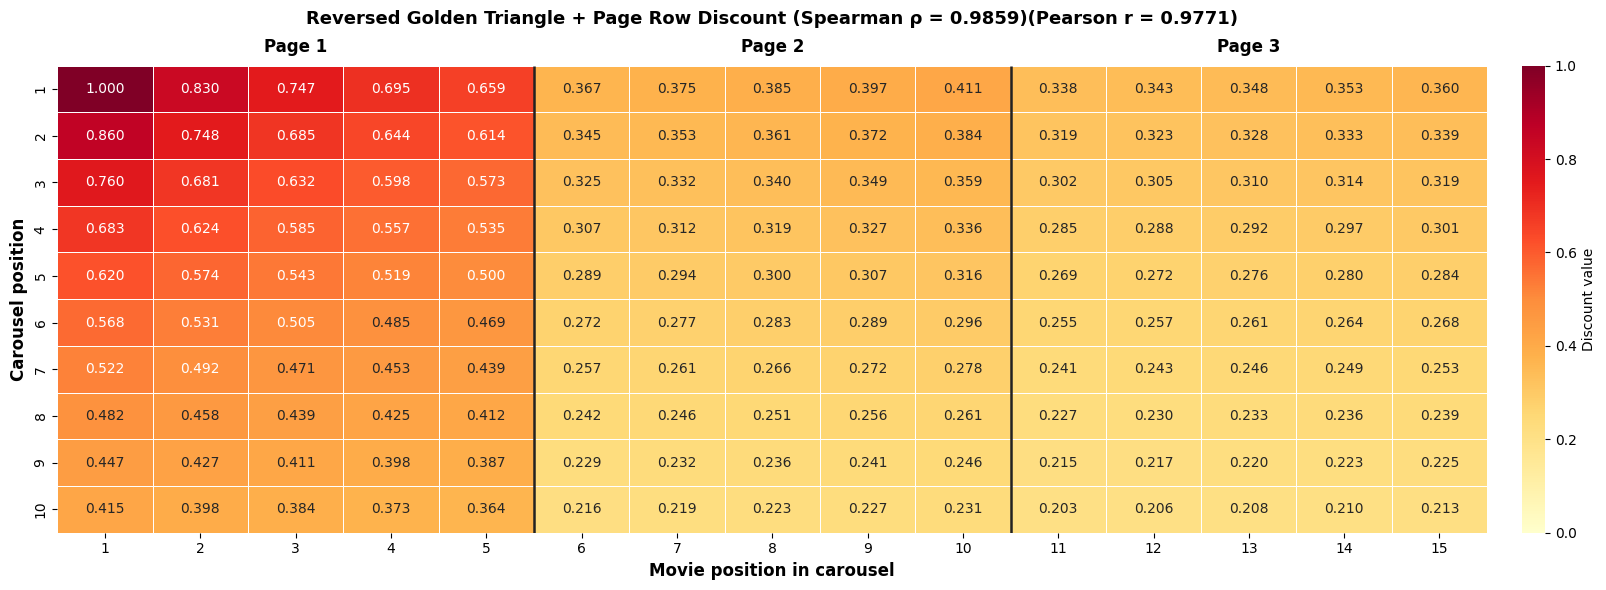

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# -----------------------------------------------------------------------------
# Grid dimensions
# -----------------------------------------------------------------------------
n_rows, n_cols = 10, 15      # 10 carousels x 15 movie slots (3 pages x 5/page)
page_size      = 5           # 5 movies per page
Vh, dh = 5, 5
Vv, dv = 3, 1


# -----------------------------------------------------------------------------
# Model parameters (from grid search)
# -----------------------------------------------------------------------------
α  = 4       # ← 填入最佳 α
β  = 9       # ← 填入最佳 β
μ  = 0.95    # ← 最佳 μ（每次垂直滑动的折扣）


g = np.zeros((n_rows, n_cols))
for i in range(n_rows):
    for j in range(n_cols):
        row = i + 1          # carousel position (1..10)
        col = j + 1          # movie position    (1..15)

        # ---------------------------------------------------------------------
        # Step 1: Locate the page and the within-page column index.
        # ---------------------------------------------------------------------
        page    = int(np.ceil(col / page_size))             # 1, 2, or 3
        k_local = col - (page - 1) * page_size              # 1..5 within page

        # ---------------------------------------------------------------------
        # Step 2: Compute effective_k (anchor reversal across pages).
        # ---------------------------------------------------------------------
        # Page 1: anchor on the left; cost increases left-to-right.
        #         eff_k = 1, 2, 3, 4, 5
        # Page 2: anchor on the right (k=10); cost increases right-to-left.
        #         eff_k = 10, 9, 8, 7, 6
        # Page 3: anchor on the right (k=15).
        #         eff_k = 15, 14, 13, 12, 11
        if page == 1:
            effective_k = k_local
        else:
            effective_k = page * page_size - k_local + 1


        if page == 1:
            h_factor = 1.0
        else:
            h_factor = 0.65

        nv = max(0, np.ceil((row - Vv) / dv))

        # Step 5
        g[i, j] = (1 / np.log2(α * row + β * effective_k)) * h_factor * (μ ** i)

g=g/g.max()
df = pd.DataFrame(g, index=range(1, 11), columns=range(1, 16))

fig, ax = plt.subplots(figsize=(18, 6))

sns.heatmap(df, cmap="YlOrRd", annot=True, fmt=".3f",
            vmin=0, vmax=1.0, linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Discount value", "pad": 0.02}, ax=ax)


ax.set_xlabel("Movie position in carousel", fontsize=12, fontweight="bold")
ax.set_ylabel("Carousel position", fontsize=12, fontweight="bold")

for x in [5, 10]:
    ax.vlines(x, *ax.get_ylim(), colors="#222222", linewidth=1.8)

for label, cc in {"Page 1": 2.5, "Page 2": 7.5, "Page 3": 12.5}.items():
    ax.text(cc / 15, 1.02, label, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=12, fontweight="bold")


rows = []
for i in range(n_rows):
    for j in range(n_cols):
        rows.append({
            'Fixation_AOI_Carousel_position': i + 1,
            'Fixation_AOI_Movie_position_in_carousel': j + 1,
            'discount': g[i, j]
        })

discount_df_7 = pd.DataFrame(rows)

freq = binary_exam_result_UvA['exam_freq'].reset_index(drop=True) / binary_exam_result_UvA['exam_freq'].reset_index(drop=True).max()


rho = freq.corr(discount_df_7['discount'].reset_index(drop=True), method='spearman')
r = freq.corr(discount_df_7['discount'].reset_index(drop=True), method='pearson')

ax.set_title(
    f"Reversed Golden Triangle + Page Row Discount "
    f"(Spearman ρ = {rho:.4f})"
    f"(Pearson r = {r:.4f})",
    fontsize=13, fontweight="bold", pad=30
)

plt.tight_layout()
plt.savefig("reversed_golden_triangle_multiplicative.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

# final figure

Best-fit candidate discount function: $d_{RPD}$ — Mirr. F-Pattern w/ Row-Page Disc.


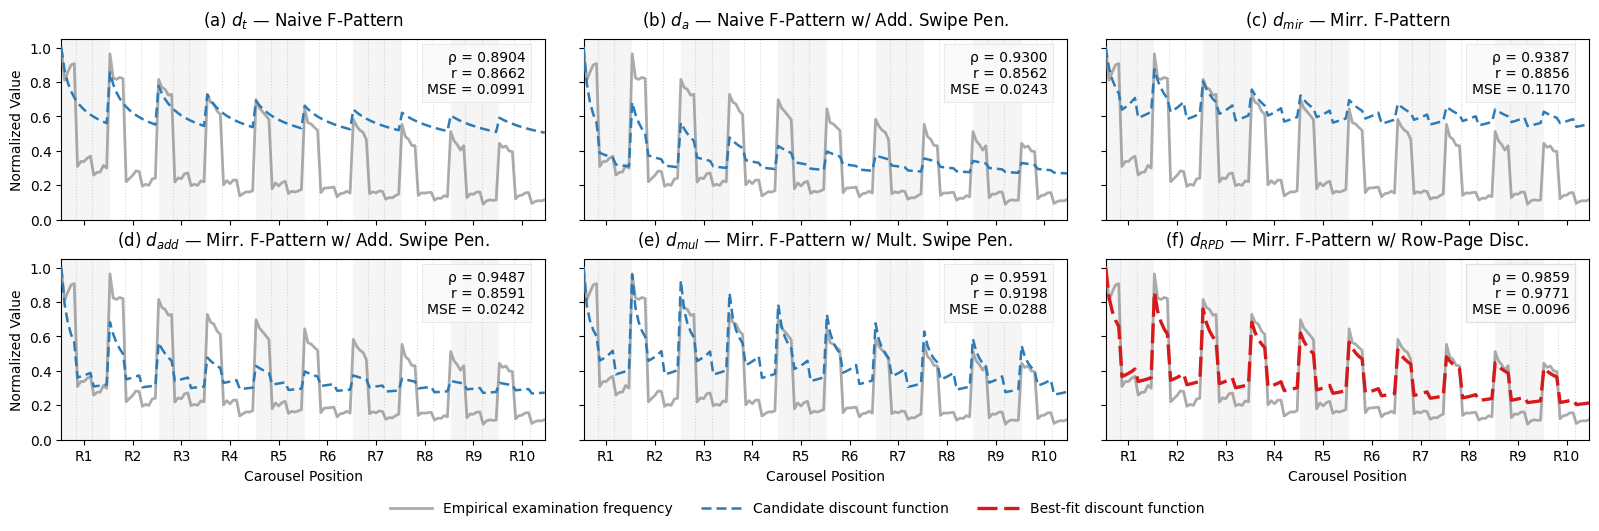


--- Metric Summary ---
                                  discount_name  spearman  pearson      mse
  $d_{RPD}$ — Mirr. F-Pattern w/ Row-Page Disc.  0.985919 0.977078 0.009584
$d_{mul}$ — Mirr. F-Pattern w/ Mult. Swipe Pen.  0.959083 0.919786 0.028766
 $d_{add}$ — Mirr. F-Pattern w/ Add. Swipe Pen.  0.948708 0.859050 0.024200
                    $d_{mir}$ — Mirr. F-Pattern  0.938685 0.885632 0.117045
     $d_a$ — Naive F-Pattern w/ Add. Swipe Pen.  0.929998 0.856210 0.024336
                        $d_t$ — Naive F-Pattern  0.890365 0.866172 0.099112


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from matplotlib.lines import Line2D

# =========================
# 1. Data preparation
# =========================
rows = binary_exam_result_UvA["Fixation_AOI_Carousel_position"].values
cols = binary_exam_result_UvA["Fixation_AOI_Movie_position_in_carousel"].values

# Anchor empirical frequency to max = 1, consistent with discount normalization
freq = (
    binary_exam_result_UvA["exam_freq"].values
    / binary_exam_result_UvA["exam_freq"].values.max()
)

# Row-major sorting
order = np.lexsort((cols, rows))
rows_sorted = rows[order]
cols_sorted = cols[order]
freq_sorted = freq[order]

# All six are candidate discount functions
discount_names = [
    r"$d_t$ — Naive F-Pattern",
    r"$d_a$ — Naive F-Pattern w/ Add. Swipe Pen.",
    r"$d_{mir}$ — Mirr. F-Pattern",
    r"$d_{add}$ — Mirr. F-Pattern w/ Add. Swipe Pen.",
    r"$d_{mul}$ — Mirr. F-Pattern w/ Mult. Swipe Pen.",
    r"$d_{RPD}$ — Mirr. F-Pattern w/ Row-Page Disc."
]

discount_dfs = [
    discount_df_2,
    discount_df_3,
    discount_df_5,
    discount_df_4,
    discount_df_6,
    discount_df_7
]

discount_flat = []

for df in discount_dfs:
    df_sorted = df.sort_values(
        [
            "Fixation_AOI_Carousel_position",
            "Fixation_AOI_Movie_position_in_carousel"
        ]
    )
    discount_flat.append(df_sorted["discount"].values)

x = np.arange(1, len(freq_sorted) + 1)

empirical_color = "#888888"
candidate_color = "#2C7BB6"
best_color = "#D7191C"

# Dash patterns
candidate_dash = (0, (4, 2))   # blue dashed
best_dash = (0, (6, 2))        # red dashed, slightly more prominent

# =========================
# 2. Metrics
# =========================
def discount_metrics(gt, pred):
    gt = np.asarray(gt, dtype=float)
    pred = np.asarray(pred, dtype=float)

    spearman, _ = spearmanr(gt, pred)
    pearson, _ = pearsonr(gt, pred)
    mse = np.mean((gt - pred) ** 2)

    return {
        "spearman": spearman,
        "pearson": pearson,
        "mse": mse
    }

# Compute metrics for all candidate discount functions
metric_results = []

for vals, name in zip(discount_flat, discount_names):
    metrics = discount_metrics(freq_sorted, vals)
    metric_results.append({
        "discount_name": name,
        **metrics
    })

metric_df = pd.DataFrame(metric_results)

# Best fit:
# primary = highest Spearman
# secondary = highest Pearson
# tertiary = lowest MSE
metric_df = metric_df.sort_values(
    by=["spearman", "pearson", "mse"],
    ascending=[False, False, True]
).reset_index(drop=True)

best_name = metric_df.loc[0, "discount_name"]
metric_lookup = metric_df.set_index("discount_name").to_dict(orient="index")

print(f"Best-fit candidate discount function: {best_name}")

# =========================
# 3. Figure setup
# =========================
fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 5.2),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

def add_position_guides(ax):
    """
    Add row-block shading and within-row position guides.
    Each carousel row contains 15 movie positions.
    Alternating row blocks are lightly shaded.
    Vertical dotted lines mark position 5 and 10 within each row.
    """
    n_rows = 10
    row_size = 15

    # Alternating row block shading
    for i in range(n_rows):
        if i % 2 == 0:
            ax.axvspan(
                i * row_size + 1,
                (i + 1) * row_size + 1,
                color="#000000",
                alpha=0.04,
                zorder=0,
                lw=0
            )

    # Within-row position guides
    for i in range(n_rows):
        for p in [5, 10]:
            xpos = i * row_size + p + 0.5
            if xpos <= n_rows * row_size:
                ax.axvline(
                    xpos,
                    color="#888888",
                    linewidth=0.8,
                    linestyle=":",
                    alpha=0.3,
                    zorder=1
                )

# =========================
# 4. Plot comparisons
# =========================
letters = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

for idx, (vals, name) in enumerate(zip(discount_flat, discount_names)):
    ax = axes[idx]
    is_best = name == best_name

    add_position_guides(ax)

    # Empirical examination frequency
    ax.plot(
        x,
        freq_sorted,
        color=empirical_color,
        linewidth=2.0,
        alpha=0.7,
        linestyle="-",
        zorder=3
    )

    # Candidate discount function
    if is_best:
        ax.plot(
            x,
            vals,
            color=best_color,
            linewidth=2.4,
            linestyle=best_dash,
            alpha=1.0,
            zorder=5
        )
    else:
        ax.plot(
            x,
            vals,
            color=candidate_color,
            linewidth=1.8,
            linestyle=candidate_dash,
            alpha=1.0,
            zorder=4
        )

    metrics = metric_lookup[name]

    # Subplot title
    ax.set_title(
        f"{letters[idx]} {name}",
        loc="center",
        pad=10
    )

    ax.set_ylim(0, 1.05)
    ax.set_xlim(1, len(freq_sorted))

    # Metrics text box
    metric_text = (
        f"ρ = {metrics['spearman']:.4f}\n"
        f"r = {metrics['pearson']:.4f}\n"
        f"MSE = {metrics['mse']:.4f}"
    )

    ax.text(
        0.96,
        0.94,
        metric_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        bbox=dict(
            boxstyle="square,pad=0.4",
            facecolor="#FAFAFA",
            edgecolor="#DDDDDD",
            linewidth=0.9 if is_best else 0.5,
            alpha=0.88
        )
    )

    if idx % 3 == 0:
        ax.set_ylabel("Normalized Value")

# =========================
# 5. X ticks
# =========================
row_centers = np.array([i * 15 + 8 for i in range(10)])
row_labels = [f"R{i + 1}" for i in range(10)]

for ax in axes[-3:]:
    ax.set_xticks(row_centers)
    ax.set_xticklabels(row_labels)
    ax.set_xlabel("Carousel Position")

# =========================
# 6. Figure-level legend and layout
# =========================
custom_lines = [
    Line2D(
        [0],
        [0],
        color=empirical_color,
        lw=2.0,
        alpha=0.7,
        linestyle="-",
        label="Empirical examination frequency"
    ),
    Line2D(
        [0],
        [0],
        color=candidate_color,
        lw=1.8,
        linestyle=candidate_dash,
        alpha=1.0,
        label="Candidate discount function"
    ),
    Line2D(
        [0],
        [0],
        color=best_color,
        lw=2.4,
        linestyle=best_dash,
        alpha=1.0,
        label="Best-fit discount function"
    )
]

fig.legend(
    handles=custom_lines,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=3,
    frameon=False,
    handlelength=3
)

fig.subplots_adjust(
    left=0.04,
    right=0.995,
    bottom=0.16,
    top=0.93,
    wspace=0.08,
    hspace=0.22
)

plt.savefig(
    "comparison_empirical_vs_candidate_discount_functions_2x3_wide.pdf",
    pad_inches=0.02
)

plt.show()

# =========================
# 7. Metric summary table
# =========================
print("\n--- Metric Summary ---")
print(
    metric_df[
        ["discount_name", "spearman", "pearson", "mse"]
    ].to_string(index=False)
)

# real simulation

In [53]:
"""
Simulation experiment: how often do the original N2DCG and our reformulated
N2DCG agree with the empirical examination-based ground truth?

Simulation design:
For each trial, we generate a fixed set of category-specific carousels.
Each carousel corresponds to one topic/category and contains a fixed candidate
set with fixed relevance labels.

Two layouts A and B are sampled from the same category-specific carousels.
They may differ in:
  (1) the vertical ordering of carousels;
  (2) the horizontal ordering of items within each carousel.

Ideal 2DCG:
The ideal ranking is topic-constrained:
  - category-specific carousels may be assigned to any display row;
  - items may be reordered within their own category carousel;
  - items cannot move across categories;
  - no additional items outside the category-specific candidate set are introduced;
  - no global uniqueness constraint is imposed across categories.

The topic-constrained ideal score is computed exactly:
  Step 1: compute S[t, r], the best row-level 2DCG if topic t is assigned to row r;
  Step 2: solve the maximum-weight topic-to-row assignment using Hungarian algorithm.
"""

import numpy as np
from collections import Counter
from scipy.optimize import linear_sum_assignment


# =============================================================================
# Configuration
# =============================================================================
V, H              = 10, 15
PAGE_SIZE         = 5

# User-action parameters used by the original 2DCG discount
Vh, dh            = 5, 5
Vv, dv            = 3, 1

# Original 2DCG parameters
ORIG = {
    "alpha": 2,
    "beta": 1,
    "gamma": 9,
    "lambda": 1,
}

# Reformulated 2DCG parameters
REF = {
    "alpha": 4,
    "beta": 9,
    "gamma": 0.65,
    "lambda": 0.95,
}

# Simulation parameters
N_TRIALS          = 20000
P_RELEVANT        = 0.15
RNG_SEED          = 42

# Relevance mode: "binary" or "graded"
RELEVANCE_MODE    = "binary"

# Avoid all-zero or all-relevant topic rows
AVOID_DEGENERATE_ROWS = True

# For graded relevance
GRADED_MIN        = 1
GRADED_MAX        = 5

# Normalized N2DCG-gap thresholds
Q_GAP_THRESHOLDS  = [0.0, 0.01, 0.02, 0.05, 0.10]


# =============================================================================
# Empirical examination probability: P_exam
# =============================================================================
# Expected external object:
# binary_exam_result_UvA is a DataFrame with column 'exam_freq',
# containing V * H empirical examination frequencies.
P_exam = binary_exam_result_UvA["exam_freq"].values.reshape(V, H)


# =============================================================================
# Discount matrices
# =============================================================================
def compute_original_discount():
    d = np.zeros((V, H), dtype=float)

    for j in range(1, V + 1):
        for k in range(1, H + 1):
            n_h = max(0, int(np.ceil((k - Vh) / dh)))
            n_v = max(0, int(np.ceil((j - Vv) / dv)))

            denom = (
                ORIG["alpha"] * j
                + ORIG["beta"] * k
                + ORIG["gamma"] * n_h
                + ORIG["lambda"] * n_v
            )

            d[j - 1, k - 1] = 1.0 / np.log2(denom)

    return d / d.max()


def compute_reformulated_discount():
    d = np.zeros((V, H), dtype=float)

    for j in range(1, V + 1):
        for k in range(1, H + 1):
            page = (k - 1) // PAGE_SIZE + 1
            k_local = k - (page - 1) * PAGE_SIZE

            if page == 1:
                eff_c = k_local
            else:
                eff_c = page * PAGE_SIZE - k_local + 1

            base = 1.0 / np.log2(REF["alpha"] * j + REF["beta"] * eff_c)
            page_penalty = REF["gamma"] if page > 1 else 1.0
            row_decay = REF["lambda"] ** (j - 1)

            d[j - 1, k - 1] = base * page_penalty * row_decay

    return d / d.max()


D_orig = compute_original_discount()
D_ref  = compute_reformulated_discount()


# Pre-sort discounts row-wise once for faster I2DCG computation
SORTED_P_exam = np.sort(P_exam, axis=1)[:, ::-1]
SORTED_D_orig = np.sort(D_orig, axis=1)[:, ::-1]
SORTED_D_ref  = np.sort(D_ref, axis=1)[:, ::-1]


# =============================================================================
# Gain, DCG, and topic-constrained ideal 2DCG
# =============================================================================
def gain(rel):
    """
    Standard DCG/NDCG gain.
    For binary relevance, this is identical to rel.
    For graded relevance, this gives exponential gain.
    """
    return 2.0 ** rel - 1.0


def get_2dcg(rel, discount_matrix):
    """
    Compute unnormalized 2DCG for a displayed layout.
    """
    return float(np.sum(gain(rel) * discount_matrix))


def compute_ideal_2dcg_topic_constrained_from_sorted(
    topic_to_items_rel,
    sorted_discount_rows,
):
    """
    Compute exact topic-constrained ideal 2DCG using pre-sorted row discounts.

    Parameters
    ----------
    topic_to_items_rel : np.ndarray, shape (K, H)
        Relevance labels for each topic-specific candidate set.

    sorted_discount_rows : np.ndarray, shape (V, H)
        Row-wise sorted positional discounts, descending.

    Returns
    -------
    float
        Topic-constrained ideal 2DCG.
    """
    topic_to_items_rel = np.asarray(topic_to_items_rel, dtype=float)
    sorted_discount_rows = np.asarray(sorted_discount_rows, dtype=float)

    K = topic_to_items_rel.shape[0]
    V_ = sorted_discount_rows.shape[0]

    if K != V_:
        raise ValueError(
            f"This implementation assumes K == V, but got K={K}, V={V_}."
        )

    # Sort topic gains once
    sorted_topic_gains = np.sort(gain(topic_to_items_rel), axis=1)[:, ::-1]

    # S[t, r] = best possible 2DCG if topic t is assigned to row r
    S = sorted_topic_gains @ sorted_discount_rows.T

    # Hungarian solves minimization, so maximize S by minimizing -S
    topic_idx, row_idx = linear_sum_assignment(-S)

    return float(S[topic_idx, row_idx].sum())


def pick(score_A, score_B):
    """
    Return preferred layout label.
    """
    if score_A > score_B:
        return "A"
    if score_B > score_A:
        return "B"
    return None


# =============================================================================
# Category-specific carousel generation
# =============================================================================
def sample_num_relevant(rng):
    n_rel = rng.binomial(H, P_RELEVANT)

    if AVOID_DEGENERATE_ROWS:
        n_rel = int(np.clip(n_rel, 1, H - 1))
    else:
        n_rel = int(np.clip(n_rel, 0, H))

    return n_rel


def generate_category_carousels(rng):
    """
    Generate V topic/category-specific candidate sets for one trial.

    Each topic has a fixed relevance composition within the trial.
    Paired layouts A and B share this same topic-level composition.
    """
    category_rows = []

    for _ in range(V):
        n_rel = sample_num_relevant(rng)

        if RELEVANCE_MODE == "binary":
            row = np.array([1] * n_rel + [0] * (H - n_rel), dtype=float)

        elif RELEVANCE_MODE == "graded":
            grades = rng.integers(GRADED_MIN, GRADED_MAX + 1, size=n_rel)
            row = np.array(list(grades) + [0] * (H - n_rel), dtype=float)

        else:
            raise ValueError("RELEVANCE_MODE must be either 'binary' or 'graded'.")

        category_rows.append(row)

    return np.array(category_rows, dtype=float)


def sample_layout_from_category_carousels(category_rows, rng):
    """
    Construct one displayed layout from fixed category-specific carousels.

    The layout can change:
        1. vertical ordering of carousels;
        2. horizontal ordering of items within each carousel.
    """
    layout = np.zeros((V, H), dtype=float)

    category_order = rng.permutation(V)

    for display_row, category_id in enumerate(category_order):
        layout[display_row] = rng.permutation(category_rows[category_id])

    return layout


def sample_pair_same_candidate_sets(rng):
    """
    Generate paired layouts A and B from the same topic-specific candidate sets.
    """
    category_rows = generate_category_carousels(rng)

    A = sample_layout_from_category_carousels(category_rows, rng)
    B = sample_layout_from_category_carousels(category_rows, rng)

    return A, B, category_rows


# =============================================================================
# Pair evaluation
# =============================================================================
def evaluate_pair(A, B, category_rows):
    """
    Evaluate one paired-layout trial.

    I2DCG denominators are computed only once per discount matrix.
    """
    idcg_exam = compute_ideal_2dcg_topic_constrained_from_sorted(
        category_rows,
        SORTED_P_exam,
    )
    idcg_orig = compute_ideal_2dcg_topic_constrained_from_sorted(
        category_rows,
        SORTED_D_orig,
    )
    idcg_ref = compute_ideal_2dcg_topic_constrained_from_sorted(
        category_rows,
        SORTED_D_ref,
    )

    if idcg_exam <= 0 or idcg_orig <= 0 or idcg_ref <= 0:
        return None

    Q_A = get_2dcg(A, P_exam) / idcg_exam
    Q_B = get_2dcg(B, P_exam) / idcg_exam

    orig_A = get_2dcg(A, D_orig) / idcg_orig
    orig_B = get_2dcg(B, D_orig) / idcg_orig

    ref_A = get_2dcg(A, D_ref) / idcg_ref
    ref_B = get_2dcg(B, D_ref) / idcg_ref

    truth = pick(Q_A, Q_B)
    op = pick(orig_A, orig_B)
    rp = pick(ref_A, ref_B)

    if truth is None or op is None or rp is None:
        return None

    return {
        "Q_A": Q_A,
        "Q_B": Q_B,
        "gap_Q": abs(Q_A - Q_B),
        "orig_A": orig_A,
        "orig_B": orig_B,
        "ref_A": ref_A,
        "ref_B": ref_B,
        "truth": truth,
        "orig_pick": op,
        "ref_pick": rp,
        "idcg_exam": idcg_exam,
        "idcg_orig": idcg_orig,
        "idcg_ref": idcg_ref,
    }


def update_counts(counts, result):
    """
    Update pairwise correctness counters.
    """
    truth = result["truth"]
    op = result["orig_pick"]
    rp = result["ref_pick"]

    oc = (op == truth)
    rc = (rp == truth)

    counts["n"] += 1
    counts["orig_correct"] += int(oc)
    counts["ref_correct"] += int(rc)
    counts["flip"] += int(not oc and rc)
    counts["orig_only"] += int(oc and not rc)
    counts["both_wrong"] += int(not oc and not rc)

    return oc, rc


# =============================================================================
# PART 0: Sanity checks
# =============================================================================
print("=" * 80)
print("Sanity check: discount matrices")
print("=" * 80)
print(f"D_orig shape: {D_orig.shape}, min={D_orig.min():.4f}, max={D_orig.max():.4f}")
print(f"D_ref  shape: {D_ref.shape}, min={D_ref.min():.4f}, max={D_ref.max():.4f}")
print(f"P_exam shape: {P_exam.shape}, min={P_exam.min():.4f}, max={P_exam.max():.4f}")


# =============================================================================
# PART 1: Headline numbers
# =============================================================================
print("\n" + "=" * 80)
print("PART 1: Headline numbers")
print("N2DCG with topic-constrained I2DCG")
print("=" * 80)

rng = np.random.default_rng(RNG_SEED)

counts = Counter()
both_wrong_records = []
gap_values = []

for trial in range(N_TRIALS):
    A, B, category_rows = sample_pair_same_candidate_sets(rng)

    if np.array_equal(A, B):
        continue

    result = evaluate_pair(A, B, category_rows)

    if result is None:
        continue

    gap_values.append(result["gap_Q"])

    oc, rc = update_counts(counts, result)

    if not oc and not rc:
        both_wrong_records.append({
            "trial": trial,
            "A": A,
            "B": B,
            "category_rows": category_rows,
            **result,
        })


n = counts["n"]

if n == 0:
    raise RuntimeError("No valid pairs were evaluated. Check simulation settings.")

print(f"\n  Total valid pairs evaluated:            {n}")
print(f"  Original N2DCG agrees with truth:       {counts['orig_correct']}/{n} ({counts['orig_correct']/n:.1%})")
print(f"  Reformulated N2DCG agrees with truth:   {counts['ref_correct']}/{n} ({counts['ref_correct']/n:.1%})")
print(f"  Flip (orig wrong, ref correct):         {counts['flip']}/{n} ({counts['flip']/n:.1%})")
print(f"  Regression (orig correct, ref wrong):   {counts['orig_only']}/{n} ({counts['orig_only']/n:.1%})")
print(f"  Both wrong:                             {counts['both_wrong']}/{n} ({counts['both_wrong']/n:.1%})")
print(
    f"  Net improvement (flip − regression):    "
    f"{counts['flip'] - counts['orig_only']}/{n} "
    f"({(counts['flip'] - counts['orig_only'])/n:+.1%})"
)


# =============================================================================
# PART 1.5: N2DCG gap distribution
# =============================================================================
gap_values = np.array(gap_values, dtype=float)

print("\n" + "=" * 80)
print("PART 1.5: Empirical N2DCG-gap distribution")
print("=" * 80)

for q in [0, 10, 25, 50, 75, 90, 95, 99, 100]:
    print(f"  {q:>3}th percentile: {np.percentile(gap_values, q):.6f}")


# =============================================================================
# PART 2: Robustness check across normalized N2DCG-gap thresholds
# =============================================================================
print("\n" + "=" * 80)
print("PART 2: Robustness check across empirical N2DCG-gap thresholds")
print("=" * 80)

print(
    f"\n{'N2DCG-gap thresh':>17} {'N':>8} {'Orig agree':>14} "
    f"{'Ref agree':>14} {'Flip':>10} {'Both wrong':>14}"
)
print("-" * 84)

for thresh in Q_GAP_THRESHOLDS:
    rng = np.random.default_rng(RNG_SEED)
    c = Counter()

    for _ in range(N_TRIALS):
        A, B, category_rows = sample_pair_same_candidate_sets(rng)

        if np.array_equal(A, B):
            continue

        result = evaluate_pair(A, B, category_rows)

        if result is None:
            continue

        if result["gap_Q"] < thresh:
            continue

        truth = result["truth"]
        op = result["orig_pick"]
        rp = result["ref_pick"]

        c["n"]  += 1
        c["oc"] += int(op == truth)
        c["rc"] += int(rp == truth)
        c["fl"] += int(op != truth and rp == truth)
        c["bw"] += int(op != truth and rp != truth)

    if c["n"] > 0:
        print(
            f"{thresh:>17.2f} {c['n']:>8} "
            f"{c['oc']/c['n']:>13.1%}  "
            f"{c['rc']/c['n']:>13.1%}  "
            f"{c['fl']/c['n']:>9.1%}  "
            f"{c['bw']/c['n']:>13.1%}"
        )
    else:
        print(
            f"{thresh:>17.2f} {0:>8} "
            f"{'-':>13}  {'-':>13}  {'-':>9}  {'-':>13}"
        )


# =============================================================================
# PART 3: Both-wrong examples
# =============================================================================
print("\n" + "=" * 80)
print("PART 3: Both-wrong examples")
print("=" * 80)

if len(both_wrong_records) > 0:
    both_wrong_records.sort(key=lambda e: e["gap_Q"])

    def format_layout(layout):
        lines = []
        for row in layout:
            tokens = []
            for x in row:
                if x <= 0:
                    tokens.append("·")
                else:
                    tokens.append(str(int(x)))
            lines.append(" ".join(tokens))
        return "\n  ".join(lines)

    def show_example(ex, label):
        print(f"\n  {label} (trial {ex['trial']}, empirical N2DCG-gap = {ex['gap_Q']:.4f}):")
        print(f"    Truth:        Q_A = {ex['Q_A']:.4f}, Q_B = {ex['Q_B']:.4f}  → {ex['truth']}")
        print(f"    Original:     {ex['orig_A']:.4f} vs {ex['orig_B']:.4f}  → {ex['orig_pick']}")
        print(f"    Reformulated: {ex['ref_A']:.4f} vs {ex['ref_B']:.4f}  → {ex['ref_pick']}")

    print("\n" + "-" * 80)
    print("5 examples with SMALLEST empirical N2DCG-gap:")
    print("-" * 80)

    for i, ex in enumerate(both_wrong_records[:5], 1):
        show_example(ex, f"Example {i}")

    print("\n" + "-" * 80)
    print("5 examples with LARGEST empirical N2DCG-gap:")
    print("-" * 80)

    for i, ex in enumerate(both_wrong_records[-5:], 1):
        show_example(ex, f"Example {i}")

    print("\n" + "=" * 80)
    print("PART 4: Layout matrices for the largest-gap both-wrong case")
    print("=" * 80)

    worst = both_wrong_records[-1]

    print(f"\n  Empirical N2DCG-gap: {worst['gap_Q']:.4f}  (truth picks {worst['truth']})")

    print(f"\n  Category-specific relevance compositions used in this trial:")
    print("  " + format_layout(worst["category_rows"]))

    print(f"\n  Layout A (Empirical N2DCG = {worst['Q_A']:.4f}):")
    print("  " + format_layout(worst["A"]))

    print(f"\n  Layout B (Empirical N2DCG = {worst['Q_B']:.4f}):")
    print("  " + format_layout(worst["B"]))

else:
    print("\n  No both-wrong examples found.")

Sanity check: discount matrices
D_orig shape: (10, 15), min=0.2683, max=1.0000
D_ref  shape: (10, 15), min=0.2034, max=1.0000
P_exam shape: (10, 15), min=0.0889, max=1.0000

PART 1: Headline numbers
N2DCG with topic-constrained I2DCG

  Total valid pairs evaluated:            19998
  Original N2DCG agrees with truth:       16582/19998 (82.9%)
  Reformulated N2DCG agrees with truth:   18631/19998 (93.2%)
  Flip (orig wrong, ref correct):         2280/19998 (11.4%)
  Regression (orig correct, ref wrong):   231/19998 (1.2%)
  Both wrong:                             1136/19998 (5.7%)
  Net improvement (flip − regression):    2049/19998 (+10.2%)

PART 1.5: Empirical N2DCG-gap distribution
    0th percentile: 0.000000
   10th percentile: 0.010766
   25th percentile: 0.027731
   50th percentile: 0.057839
   75th percentile: 0.099498
   90th percentile: 0.143348
   95th percentile: 0.171465
   99th percentile: 0.227011
  100th percentile: 0.422337

PART 2: Robustness check across empirical N2D

In [54]:
"""
Simulation experiment: how often do the original N2DCG and our reformulated
N2DCG agree with the empirical examination-based ground truth?

Simulation design:
For each trial, we generate a fixed set of category-specific carousels.
Each carousel corresponds to one topic/category and contains a fixed candidate
set with fixed relevance labels.

Two layouts A and B are sampled from the same category-specific carousels.
They may differ in:
  (1) the vertical ordering of carousels;
  (2) the horizontal ordering of items within each carousel.

Ideal 2DCG:
The ideal ranking is topic-constrained:
  - category-specific carousels may be assigned to any display row;
  - items may be reordered within their own category carousel;
  - items cannot move across categories;
  - no additional items outside the category-specific candidate set are introduced;
  - no global uniqueness constraint is imposed across categories.

The topic-constrained ideal score is computed exactly:
  Step 1: compute S[t, r], the best row-level 2DCG if topic t is assigned to row r;
  Step 2: solve the maximum-weight topic-to-row assignment using Hungarian algorithm.
"""

import numpy as np
from collections import Counter
from scipy.optimize import linear_sum_assignment


# =============================================================================
# Configuration
# =============================================================================
V, H              = 10, 15
PAGE_SIZE         = 5

# User-action parameters used by the original 2DCG discount
Vh, dh            = 5, 5
Vv, dv            = 3, 1

# Original 2DCG parameters
ORIG = {
    "alpha": 2,
    "beta": 1,
    "gamma": 9,
    "lambda": 1,
}

# Reformulated 2DCG parameters
REF = {
    "alpha": 4,
    "beta": 9,
    "gamma": 0.65,
    "lambda": 0.95,
}

# Simulation parameters
N_TRIALS          = 20000
P_RELEVANT        = 0.15
RNG_SEED          = 42

# Relevance mode: "binary" or "graded"
RELEVANCE_MODE    = "graded"

# Avoid all-zero or all-relevant topic rows
AVOID_DEGENERATE_ROWS = True

# For graded relevance
GRADED_MIN        = 1
GRADED_MAX        = 5

# Normalized N2DCG-gap thresholds
Q_GAP_THRESHOLDS  = [0.0, 0.01, 0.02, 0.05, 0.10]


# =============================================================================
# Empirical examination probability: P_exam
# =============================================================================
# Expected external object:
# binary_exam_result_UvA is a DataFrame with column 'exam_freq',
# containing V * H empirical examination frequencies.
P_exam = binary_exam_result_UvA["exam_freq"].values.reshape(V, H)


# =============================================================================
# Discount matrices
# =============================================================================
def compute_original_discount():
    d = np.zeros((V, H), dtype=float)

    for j in range(1, V + 1):
        for k in range(1, H + 1):
            n_h = max(0, int(np.ceil((k - Vh) / dh)))
            n_v = max(0, int(np.ceil((j - Vv) / dv)))

            denom = (
                ORIG["alpha"] * j
                + ORIG["beta"] * k
                + ORIG["gamma"] * n_h
                + ORIG["lambda"] * n_v
            )

            d[j - 1, k - 1] = 1.0 / np.log2(denom)

    return d / d.max()


def compute_reformulated_discount():
    d = np.zeros((V, H), dtype=float)

    for j in range(1, V + 1):
        for k in range(1, H + 1):
            page = (k - 1) // PAGE_SIZE + 1
            k_local = k - (page - 1) * PAGE_SIZE

            if page == 1:
                eff_c = k_local
            else:
                eff_c = page * PAGE_SIZE - k_local + 1

            base = 1.0 / np.log2(REF["alpha"] * j + REF["beta"] * eff_c)
            page_penalty = REF["gamma"] if page > 1 else 1.0
            row_decay = REF["lambda"] ** (j - 1)

            d[j - 1, k - 1] = base * page_penalty * row_decay

    return d / d.max()


D_orig = compute_original_discount()
D_ref  = compute_reformulated_discount()


# Pre-sort discounts row-wise once for faster I2DCG computation
SORTED_P_exam = np.sort(P_exam, axis=1)[:, ::-1]
SORTED_D_orig = np.sort(D_orig, axis=1)[:, ::-1]
SORTED_D_ref  = np.sort(D_ref, axis=1)[:, ::-1]


# =============================================================================
# Gain, DCG, and topic-constrained ideal 2DCG
# =============================================================================
def gain(rel):
    """
    Standard DCG/NDCG gain.
    For binary relevance, this is identical to rel.
    For graded relevance, this gives exponential gain.
    """
    return 2.0 ** rel - 1.0


def get_2dcg(rel, discount_matrix):
    """
    Compute unnormalized 2DCG for a displayed layout.
    """
    return float(np.sum(gain(rel) * discount_matrix))


def compute_ideal_2dcg_topic_constrained_from_sorted(
    topic_to_items_rel,
    sorted_discount_rows,
):
    """
    Compute exact topic-constrained ideal 2DCG using pre-sorted row discounts.

    Parameters
    ----------
    topic_to_items_rel : np.ndarray, shape (K, H)
        Relevance labels for each topic-specific candidate set.

    sorted_discount_rows : np.ndarray, shape (V, H)
        Row-wise sorted positional discounts, descending.

    Returns
    -------
    float
        Topic-constrained ideal 2DCG.
    """
    topic_to_items_rel = np.asarray(topic_to_items_rel, dtype=float)
    sorted_discount_rows = np.asarray(sorted_discount_rows, dtype=float)

    K = topic_to_items_rel.shape[0]
    V_ = sorted_discount_rows.shape[0]

    if K != V_:
        raise ValueError(
            f"This implementation assumes K == V, but got K={K}, V={V_}."
        )

    # Sort topic gains once
    sorted_topic_gains = np.sort(gain(topic_to_items_rel), axis=1)[:, ::-1]

    # S[t, r] = best possible 2DCG if topic t is assigned to row r
    S = sorted_topic_gains @ sorted_discount_rows.T

    # Hungarian solves minimization, so maximize S by minimizing -S
    topic_idx, row_idx = linear_sum_assignment(-S)

    return float(S[topic_idx, row_idx].sum())


def pick(score_A, score_B):
    """
    Return preferred layout label.
    """
    if score_A > score_B:
        return "A"
    if score_B > score_A:
        return "B"
    return None


# =============================================================================
# Category-specific carousel generation
# =============================================================================
def sample_num_relevant(rng):
    n_rel = rng.binomial(H, P_RELEVANT)

    if AVOID_DEGENERATE_ROWS:
        n_rel = int(np.clip(n_rel, 1, H - 1))
    else:
        n_rel = int(np.clip(n_rel, 0, H))

    return n_rel


def generate_category_carousels(rng):
    """
    Generate V topic/category-specific candidate sets for one trial.

    Each topic has a fixed relevance composition within the trial.
    Paired layouts A and B share this same topic-level composition.
    """
    category_rows = []

    for _ in range(V):
        n_rel = sample_num_relevant(rng)

        if RELEVANCE_MODE == "binary":
            row = np.array([1] * n_rel + [0] * (H - n_rel), dtype=float)

        elif RELEVANCE_MODE == "graded":
            grades = rng.integers(GRADED_MIN, GRADED_MAX + 1, size=n_rel)
            row = np.array(list(grades) + [0] * (H - n_rel), dtype=float)

        else:
            raise ValueError("RELEVANCE_MODE must be either 'binary' or 'graded'.")

        category_rows.append(row)

    return np.array(category_rows, dtype=float)


def sample_layout_from_category_carousels(category_rows, rng):
    """
    Construct one displayed layout from fixed category-specific carousels.

    The layout can change:
        1. vertical ordering of carousels;
        2. horizontal ordering of items within each carousel.
    """
    layout = np.zeros((V, H), dtype=float)

    category_order = rng.permutation(V)

    for display_row, category_id in enumerate(category_order):
        layout[display_row] = rng.permutation(category_rows[category_id])

    return layout


def sample_pair_same_candidate_sets(rng):
    """
    Generate paired layouts A and B from the same topic-specific candidate sets.
    """
    category_rows = generate_category_carousels(rng)

    A = sample_layout_from_category_carousels(category_rows, rng)
    B = sample_layout_from_category_carousels(category_rows, rng)

    return A, B, category_rows


# =============================================================================
# Pair evaluation
# =============================================================================
def evaluate_pair(A, B, category_rows):
    """
    Evaluate one paired-layout trial.

    I2DCG denominators are computed only once per discount matrix.
    """
    idcg_exam = compute_ideal_2dcg_topic_constrained_from_sorted(
        category_rows,
        SORTED_P_exam,
    )
    idcg_orig = compute_ideal_2dcg_topic_constrained_from_sorted(
        category_rows,
        SORTED_D_orig,
    )
    idcg_ref = compute_ideal_2dcg_topic_constrained_from_sorted(
        category_rows,
        SORTED_D_ref,
    )

    if idcg_exam <= 0 or idcg_orig <= 0 or idcg_ref <= 0:
        return None

    Q_A = get_2dcg(A, P_exam) / idcg_exam
    Q_B = get_2dcg(B, P_exam) / idcg_exam

    orig_A = get_2dcg(A, D_orig) / idcg_orig
    orig_B = get_2dcg(B, D_orig) / idcg_orig

    ref_A = get_2dcg(A, D_ref) / idcg_ref
    ref_B = get_2dcg(B, D_ref) / idcg_ref

    truth = pick(Q_A, Q_B)
    op = pick(orig_A, orig_B)
    rp = pick(ref_A, ref_B)

    if truth is None or op is None or rp is None:
        return None

    return {
        "Q_A": Q_A,
        "Q_B": Q_B,
        "gap_Q": abs(Q_A - Q_B),
        "orig_A": orig_A,
        "orig_B": orig_B,
        "ref_A": ref_A,
        "ref_B": ref_B,
        "truth": truth,
        "orig_pick": op,
        "ref_pick": rp,
        "idcg_exam": idcg_exam,
        "idcg_orig": idcg_orig,
        "idcg_ref": idcg_ref,
    }


def update_counts(counts, result):
    """
    Update pairwise correctness counters.
    """
    truth = result["truth"]
    op = result["orig_pick"]
    rp = result["ref_pick"]

    oc = (op == truth)
    rc = (rp == truth)

    counts["n"] += 1
    counts["orig_correct"] += int(oc)
    counts["ref_correct"] += int(rc)
    counts["flip"] += int(not oc and rc)
    counts["orig_only"] += int(oc and not rc)
    counts["both_wrong"] += int(not oc and not rc)

    return oc, rc


# =============================================================================
# PART 0: Sanity checks
# =============================================================================
print("=" * 80)
print("Sanity check: discount matrices")
print("=" * 80)
print(f"D_orig shape: {D_orig.shape}, min={D_orig.min():.4f}, max={D_orig.max():.4f}")
print(f"D_ref  shape: {D_ref.shape}, min={D_ref.min():.4f}, max={D_ref.max():.4f}")
print(f"P_exam shape: {P_exam.shape}, min={P_exam.min():.4f}, max={P_exam.max():.4f}")


# =============================================================================
# PART 1: Headline numbers
# =============================================================================
print("\n" + "=" * 80)
print("PART 1: Headline numbers")
print("N2DCG with topic-constrained I2DCG")
print("=" * 80)

rng = np.random.default_rng(RNG_SEED)

counts = Counter()
both_wrong_records = []
gap_values = []

for trial in range(N_TRIALS):
    A, B, category_rows = sample_pair_same_candidate_sets(rng)

    if np.array_equal(A, B):
        continue

    result = evaluate_pair(A, B, category_rows)

    if result is None:
        continue

    gap_values.append(result["gap_Q"])

    oc, rc = update_counts(counts, result)

    if not oc and not rc:
        both_wrong_records.append({
            "trial": trial,
            "A": A,
            "B": B,
            "category_rows": category_rows,
            **result,
        })


n = counts["n"]

if n == 0:
    raise RuntimeError("No valid pairs were evaluated. Check simulation settings.")

print(f"\n  Total valid pairs evaluated:            {n}")
print(f"  Original N2DCG agrees with truth:       {counts['orig_correct']}/{n} ({counts['orig_correct']/n:.1%})")
print(f"  Reformulated N2DCG agrees with truth:   {counts['ref_correct']}/{n} ({counts['ref_correct']/n:.1%})")
print(f"  Flip (orig wrong, ref correct):         {counts['flip']}/{n} ({counts['flip']/n:.1%})")
print(f"  Regression (orig correct, ref wrong):   {counts['orig_only']}/{n} ({counts['orig_only']/n:.1%})")
print(f"  Both wrong:                             {counts['both_wrong']}/{n} ({counts['both_wrong']/n:.1%})")
print(
    f"  Net improvement (flip − regression):    "
    f"{counts['flip'] - counts['orig_only']}/{n} "
    f"({(counts['flip'] - counts['orig_only'])/n:+.1%})"
)


# =============================================================================
# PART 1.5: N2DCG gap distribution
# =============================================================================
gap_values = np.array(gap_values, dtype=float)

print("\n" + "=" * 80)
print("PART 1.5: Empirical N2DCG-gap distribution")
print("=" * 80)

for q in [0, 10, 25, 50, 75, 90, 95, 99, 100]:
    print(f"  {q:>3}th percentile: {np.percentile(gap_values, q):.6f}")


# =============================================================================
# PART 2: Robustness check across normalized N2DCG-gap thresholds
# =============================================================================
print("\n" + "=" * 80)
print("PART 2: Robustness check across empirical N2DCG-gap thresholds")
print("=" * 80)

print(
    f"\n{'N2DCG-gap thresh':>17} {'N':>8} {'Orig agree':>14} "
    f"{'Ref agree':>14} {'Flip':>10} {'Both wrong':>14}"
)
print("-" * 84)

for thresh in Q_GAP_THRESHOLDS:
    rng = np.random.default_rng(RNG_SEED)
    c = Counter()

    for _ in range(N_TRIALS):
        A, B, category_rows = sample_pair_same_candidate_sets(rng)

        if np.array_equal(A, B):
            continue

        result = evaluate_pair(A, B, category_rows)

        if result is None:
            continue

        if result["gap_Q"] < thresh:
            continue

        truth = result["truth"]
        op = result["orig_pick"]
        rp = result["ref_pick"]

        c["n"]  += 1
        c["oc"] += int(op == truth)
        c["rc"] += int(rp == truth)
        c["fl"] += int(op != truth and rp == truth)
        c["bw"] += int(op != truth and rp != truth)

    if c["n"] > 0:
        print(
            f"{thresh:>17.2f} {c['n']:>8} "
            f"{c['oc']/c['n']:>13.1%}  "
            f"{c['rc']/c['n']:>13.1%}  "
            f"{c['fl']/c['n']:>9.1%}  "
            f"{c['bw']/c['n']:>13.1%}"
        )
    else:
        print(
            f"{thresh:>17.2f} {0:>8} "
            f"{'-':>13}  {'-':>13}  {'-':>9}  {'-':>13}"
        )


# =============================================================================
# PART 3: Both-wrong examples
# =============================================================================
print("\n" + "=" * 80)
print("PART 3: Both-wrong examples")
print("=" * 80)

if len(both_wrong_records) > 0:
    both_wrong_records.sort(key=lambda e: e["gap_Q"])

    def format_layout(layout):
        lines = []
        for row in layout:
            tokens = []
            for x in row:
                if x <= 0:
                    tokens.append("·")
                else:
                    tokens.append(str(int(x)))
            lines.append(" ".join(tokens))
        return "\n  ".join(lines)

    def show_example(ex, label):
        print(f"\n  {label} (trial {ex['trial']}, empirical N2DCG-gap = {ex['gap_Q']:.4f}):")
        print(f"    Truth:        Q_A = {ex['Q_A']:.4f}, Q_B = {ex['Q_B']:.4f}  → {ex['truth']}")
        print(f"    Original:     {ex['orig_A']:.4f} vs {ex['orig_B']:.4f}  → {ex['orig_pick']}")
        print(f"    Reformulated: {ex['ref_A']:.4f} vs {ex['ref_B']:.4f}  → {ex['ref_pick']}")

    print("\n" + "-" * 80)
    print("5 examples with SMALLEST empirical N2DCG-gap:")
    print("-" * 80)

    for i, ex in enumerate(both_wrong_records[:5], 1):
        show_example(ex, f"Example {i}")

    print("\n" + "-" * 80)
    print("5 examples with LARGEST empirical N2DCG-gap:")
    print("-" * 80)

    for i, ex in enumerate(both_wrong_records[-5:], 1):
        show_example(ex, f"Example {i}")

    print("\n" + "=" * 80)
    print("PART 4: Layout matrices for the largest-gap both-wrong case")
    print("=" * 80)

    worst = both_wrong_records[-1]

    print(f"\n  Empirical N2DCG-gap: {worst['gap_Q']:.4f}  (truth picks {worst['truth']})")

    print(f"\n  Category-specific relevance compositions used in this trial:")
    print("  " + format_layout(worst["category_rows"]))

    print(f"\n  Layout A (Empirical N2DCG = {worst['Q_A']:.4f}):")
    print("  " + format_layout(worst["A"]))

    print(f"\n  Layout B (Empirical N2DCG = {worst['Q_B']:.4f}):")
    print("  " + format_layout(worst["B"]))

else:
    print("\n  No both-wrong examples found.")

Sanity check: discount matrices
D_orig shape: (10, 15), min=0.2683, max=1.0000
D_ref  shape: (10, 15), min=0.2034, max=1.0000
P_exam shape: (10, 15), min=0.0889, max=1.0000

PART 1: Headline numbers
N2DCG with topic-constrained I2DCG

  Total valid pairs evaluated:            20000
  Original N2DCG agrees with truth:       16978/20000 (84.9%)
  Reformulated N2DCG agrees with truth:   18770/20000 (93.8%)
  Flip (orig wrong, ref correct):         2071/20000 (10.4%)
  Regression (orig correct, ref wrong):   279/20000 (1.4%)
  Both wrong:                             951/20000 (4.8%)
  Net improvement (flip − regression):    1792/20000 (+9.0%)

PART 1.5: Empirical N2DCG-gap distribution
    0th percentile: 0.000000
   10th percentile: 0.014421
   25th percentile: 0.036414
   50th percentile: 0.076773
   75th percentile: 0.131626
   90th percentile: 0.188182
   95th percentile: 0.226149
   99th percentile: 0.296195
  100th percentile: 0.504790

PART 2: Robustness check across empirical N2DCG